# 🏏 IPL Dynasty Analytics: 19 Seasons of Dominance, Collapse & Clutch Performance

> **A deep-dive into every IPL season from 2008–2026** — combining statistical rigor, ML models, SHAP explainability, network graphs, and animated timelines to answer the questions every cricket fan argues about.

---
**Sections**
1. [Who Was the True IPL Dynasty?](#dynasty)
2. [Toss Myth Busted](#toss)
3. [Venue Advantage Index](#venue)
4. [Clutch Team Index](#clutch)
5. [Empire Rise & Fall — Animated Timeline](#empire)
6. [Player of Match Kings](#pom)
7. [Team Similarity Network](#network)
8. [Predict Match Winners (CatBoost / XGBoost / LightGBM)](#ml)
9. [SHAP Analysis — What Actually Matters?](#shap)
10. [IPL Era Detection with UMAP](#era)

---
*Data: 1,243 matches across 19 IPL seasons (2008–2026)*


In [1]:
# ───────────────────────────────────────────────
#  IMPORTS & GLOBAL SETTINGS
# ───────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import glob, re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from collections import defaultdict

# ML
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap

# Graph
import networkx as nx

# UMAP
import umap

# Animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import matplotlib.cm as cm

# ── Global style ──────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#161b22',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.linewidth':    0.6,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        130,
})

TEAM_COLORS = {
    'Chennai Super Kings':           '#f5db00',
    'Mumbai Indians':                '#004ba0',
    'Royal Challengers Bangalore':   '#d4001c',
    'Royal Challengers Bengaluru':   '#d4001c',
    'Kolkata Knight Riders':         '#9b59b6',
    'Delhi Capitals':                '#1a76d2',
    'Delhi Daredevils':              '#1a76d2',
    'Sunrisers Hyderabad':           '#ff822a',
    'Rajasthan Royals':              '#ff4e80',
    'Punjab Kings':                  '#d71920',
    'Kings XI Punjab':               '#d71920',
    'Lucknow Super Giants':          '#00b4d8',
    'Gujarat Titans':                '#1b6ca8',
    'Deccan Chargers':               '#ffd700',
    'Rising Pune Supergiant':        '#6a0572',
    'Kochi Tuskers Kerala':          '#e67e22',
    'Pune Warriors':                 '#0099cc',
}

def team_color(name):
    for k, v in TEAM_COLORS.items():
        if k in str(name):
            return v
    return '#8b949e'

print("✅  All libraries loaded")


✅  All libraries loaded


In [2]:
# ───────────────────────────────────────────────
#  DATA LOADING — 19 SEASON FILES
# ───────────────────────────────────────────────
import os

# Auto-detect path (works on Kaggle and locally)
BASE_DIRS = [
    '/kaggle/input',
    '/mnt/user-data/uploads',
    '.'
]

def find_files(pattern):
    for d in BASE_DIRS:
        files = sorted(glob.glob(os.path.join(d, '**', pattern), recursive=True))
        if files:
            return files
    return []

year_files = find_files('ipl_matches_20*.csv')
print(f"Found {len(year_files)} season files")

dfs = []
for f in year_files:
    df = pd.read_csv(f)
    dfs.append(df)

df_raw = pd.concat(dfs, ignore_index=True)

# ── Season normalisation ──
def norm_season(s):
    s = str(s)
    if '/' in s:
        return int(s.split('/')[0]) + 1   # 2007/08 → 2008
    return int(s)

df_raw['year'] = df_raw['season'].apply(norm_season)

# ── Team name harmonisation ──
TEAM_MAP = {
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant':      'Rising Pune Supergiants',
    'Delhi Daredevils':            'Delhi Capitals',
    'Kings XI Punjab':             'Punjab Kings',
    'Deccan Chargers':             'Deccan Chargers',
}
for col in ['team1', 'team2', 'winner', 'toss_winner']:
    df_raw[col] = df_raw[col].replace(TEAM_MAP)

df = df_raw.copy()

# ── Basic checks ──
print(f"Total matches  : {len(df):,}")
print(f"Seasons        : {sorted(df['year'].unique())}")
print(f"Unique teams   : {df['team1'].nunique()}")
print(f"Null winners   : {df['winner'].isna().sum()}")
df.head(3)


Found 19 season files
Total matches  : 1,243
Seasons        : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Unique teams   : 15
Null winners   : 25


,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players,year
0,2008-04-18,2007/08,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,82,10,...,BB McCullum,J Srinath,Asad Rauf,RE Koertzen,AM Saheba,VN Kulkarni,20,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",2008
1,2008-04-19,2007/08,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,207,4,...,MEK Hussey,S Venkataraghavan,MR Benson,SL Shastri,RB Tiffin,MSS Ranawat,20,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",2008
2,2008-04-19,2007/08,Delhi,Feroz Shah Kotla,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,132,1,...,MF Maharoof,GR Viswanath,Aleem Dar,GA Pratapkumar,IL Howell,Unknown,20,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",2008


---
## 🏆 Section 1 — Who Was the True IPL Dynasty? <a id='dynasty'></a>
*We score teams on Win %, Longevity, Consistency (std-dev of win%), and Home Dominance.*

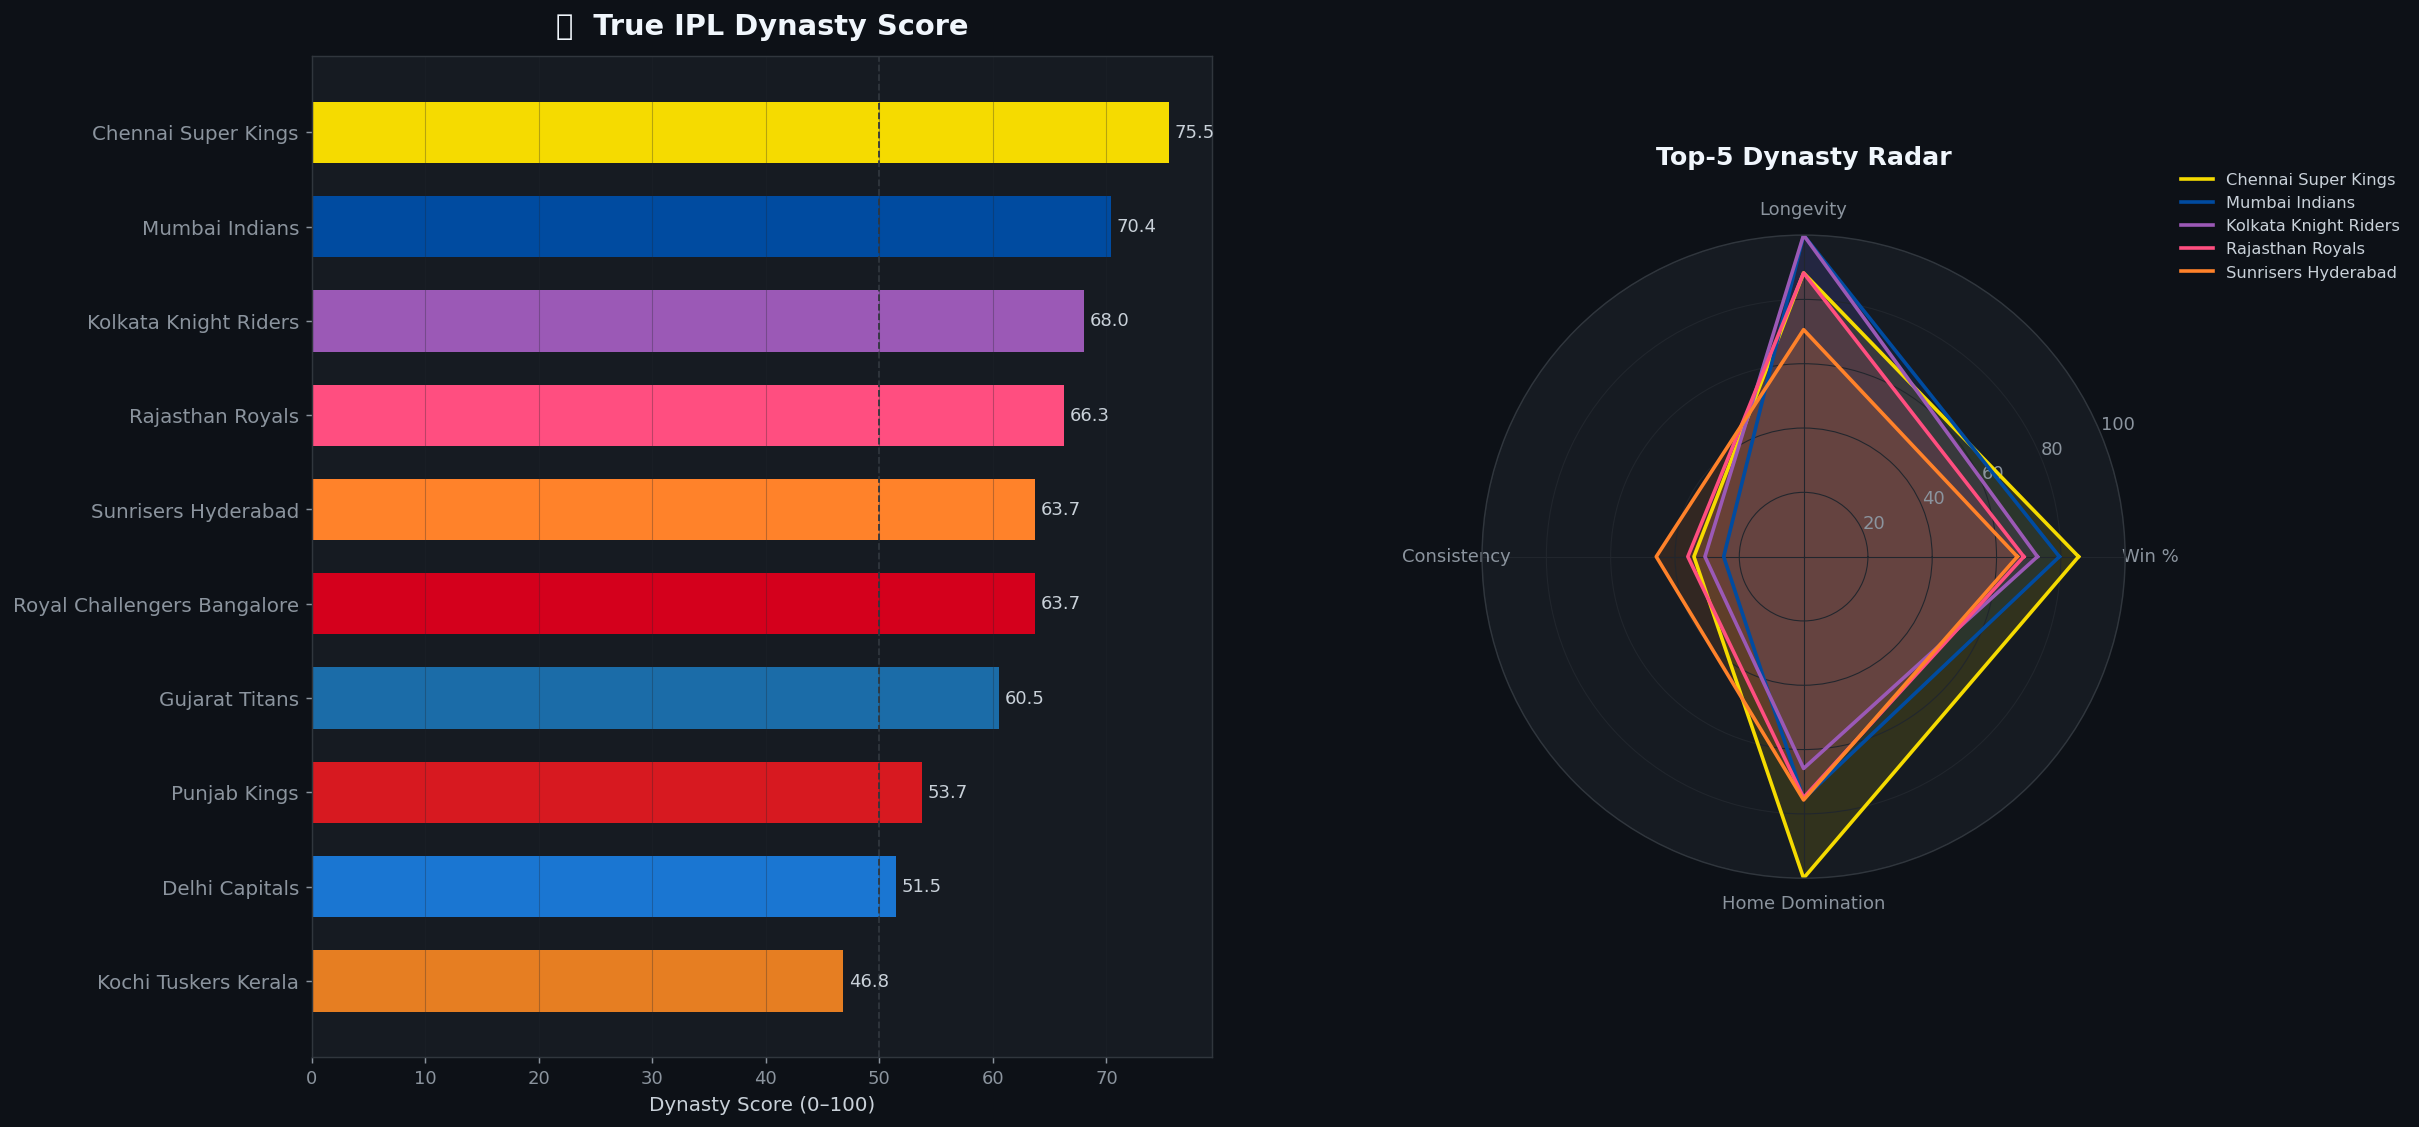


📊 Dynasty Leaderboard
                             wins  played  win_pct  longevity  consistency  home_win_pct  dynasty_score
team                                                                                                   
Chennai Super Kings           148     264     56.1         16         87.5          64.9           75.5
Mumbai Indians                155     287     54.0         18         85.8          59.2           70.4
Kolkata Knight Riders         140     271     51.7         18         86.9          57.0           68.0
Rajasthan Royals              123     245     50.2         16         87.9          59.1           66.3
Sunrisers Hyderabad           102     206     49.5         13         89.7          59.3           63.7
Royal Challengers Bangalore   143     280     51.1         18         87.0          51.0           63.7
Gujarat Titans                 47      77     61.0          5         87.9          58.1           60.5
Punjab Kings                  126     271

In [3]:
# ── Build per-team-per-year stats ────────────────
records = []
for _, row in df.iterrows():
    if pd.isna(row['winner']): continue
    for team in [row['team1'], row['team2']]:
        won = int(row['winner'] == team)
        home_venue = str(row['venue'])
        # rough home detection: CSK→Chennai, MI→Mumbai, etc.
        home_map = {
            'Chennai Super Kings':        'Chepauk',
            'Mumbai Indians':             'Wankhede',
            'Royal Challengers Bangalore':'Chinnaswamy',
            'Kolkata Knight Riders':      'Eden',
            'Sunrisers Hyderabad':        'Uppal',
            'Rajasthan Royals':           'Sawai',
            'Delhi Capitals':             'Kotla',
            'Punjab Kings':               'Mohali',
            'Lucknow Super Giants':       'Ekana',
            'Gujarat Titans':             'Narendra Modi',
        }
        is_home = any(kw.lower() in home_venue.lower()
                      for kw in [home_map.get(team, 'XXXXX')])
        records.append({'team': team, 'year': row['year'],
                        'won': won, 'is_home': is_home})

match_df = pd.DataFrame(records)

# Per team overall
g = match_df.groupby('team')
team_stats = g['won'].agg(['sum','count']).rename(columns={'sum':'wins','count':'played'})
team_stats['win_pct']    = team_stats['wins'] / team_stats['played'] * 100
team_stats['longevity']  = match_df.groupby('team')['year'].nunique()

# Per team per year win%
yr_win = match_df.groupby(['team','year'])['won'].mean().reset_index()
team_stats['consistency'] = 100 - yr_win.groupby('team')['won'].std().fillna(0) * 100

# Home win%
home_df = match_df[match_df['is_home']]
home_wp  = home_df.groupby('team')['won'].mean() * 100
team_stats['home_win_pct'] = home_wp

# Normalise to 0-100 then composite
from sklearn.preprocessing import MinMaxScaler
cols = ['win_pct','longevity','consistency','home_win_pct']
ts2 = team_stats[cols].copy().fillna(50)
sc  = MinMaxScaler((0, 100))
ts_norm = pd.DataFrame(sc.fit_transform(ts2), index=ts2.index, columns=cols)
weights = {'win_pct':0.35, 'longevity':0.25, 'consistency':0.25, 'home_win_pct':0.15}
ts_norm['dynasty_score'] = sum(ts_norm[c]*w for c,w in weights.items())
team_stats['dynasty_score'] = ts_norm['dynasty_score']

top_teams = team_stats.sort_values('dynasty_score', ascending=False).head(10)

# ── PLOT ────────────────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
gs  = GridSpec(1, 2, figure=fig, width_ratios=[1.4, 1], wspace=0.35)

# left: horizontal bar — dynasty score
ax1 = fig.add_subplot(gs[0])
colors_bar = [team_color(t) for t in top_teams.index]
bars = ax1.barh(range(len(top_teams)), top_teams['dynasty_score'],
                color=colors_bar, edgecolor='none', height=0.65)
ax1.set_yticks(range(len(top_teams)))
ax1.set_yticklabels(top_teams.index, fontsize=11)
ax1.set_xlabel('Dynasty Score (0–100)', fontsize=11)
ax1.set_title('🏆  True IPL Dynasty Score', fontsize=16, fontweight='bold', color='#f0f6fc', pad=12)
ax1.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top_teams['dynasty_score'])):
    ax1.text(val + 0.5, i, f'{val:.1f}', va='center', fontsize=10, color='#c9d1d9')
ax1.axvline(x=50, color='#30363d', lw=1, ls='--')
ax1.grid(axis='x', alpha=0.3)

# right: radar for top 5
ax2 = fig.add_subplot(gs[1], polar=True)
cats  = ['Win %', 'Longevity', 'Consistency', 'Home Domination']
N     = len(cats)
angles = [n / N * 2 * np.pi for n in range(N)]
angles += angles[:1]

top5 = top_teams.head(5)
for tm in top5.index:
    row_vals = [ts_norm.loc[tm, c] for c in cols]
    row_vals += row_vals[:1]
    ax2.plot(angles, row_vals, color=team_color(tm), lw=2, label=tm)
    ax2.fill(angles, row_vals, color=team_color(tm), alpha=0.12)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(cats, fontsize=10, color='#c9d1d9')
ax2.set_ylim(0, 100)
ax2.set_facecolor('#161b22')
ax2.tick_params(colors='#8b949e')
ax2.legend(loc='upper right', bbox_to_anchor=(1.45, 1.12), fontsize=9,
           framealpha=0, labelcolor='#c9d1d9')
ax2.set_title('Top-5 Dynasty Radar', fontsize=14, fontweight='bold',
              color='#f0f6fc', pad=20)

plt.suptitle('', y=1)
plt.tight_layout()
plt.savefig('dynasty.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()

print("\n📊 Dynasty Leaderboard")
print(top_teams[['wins','played','win_pct','longevity','consistency','home_win_pct','dynasty_score']]
      .round(1).to_string())


---
## 🎯 Section 2 — Toss Myth Busted <a id='toss'></a>

Chi-squared test: χ²=9.12, p=0.0025
Verdict: ✅ Statistically significant  (α=0.05)

Overall toss-winner also wins the match: 51.6%
Bat first & win: 45.3%
Field first & win: 54.7%


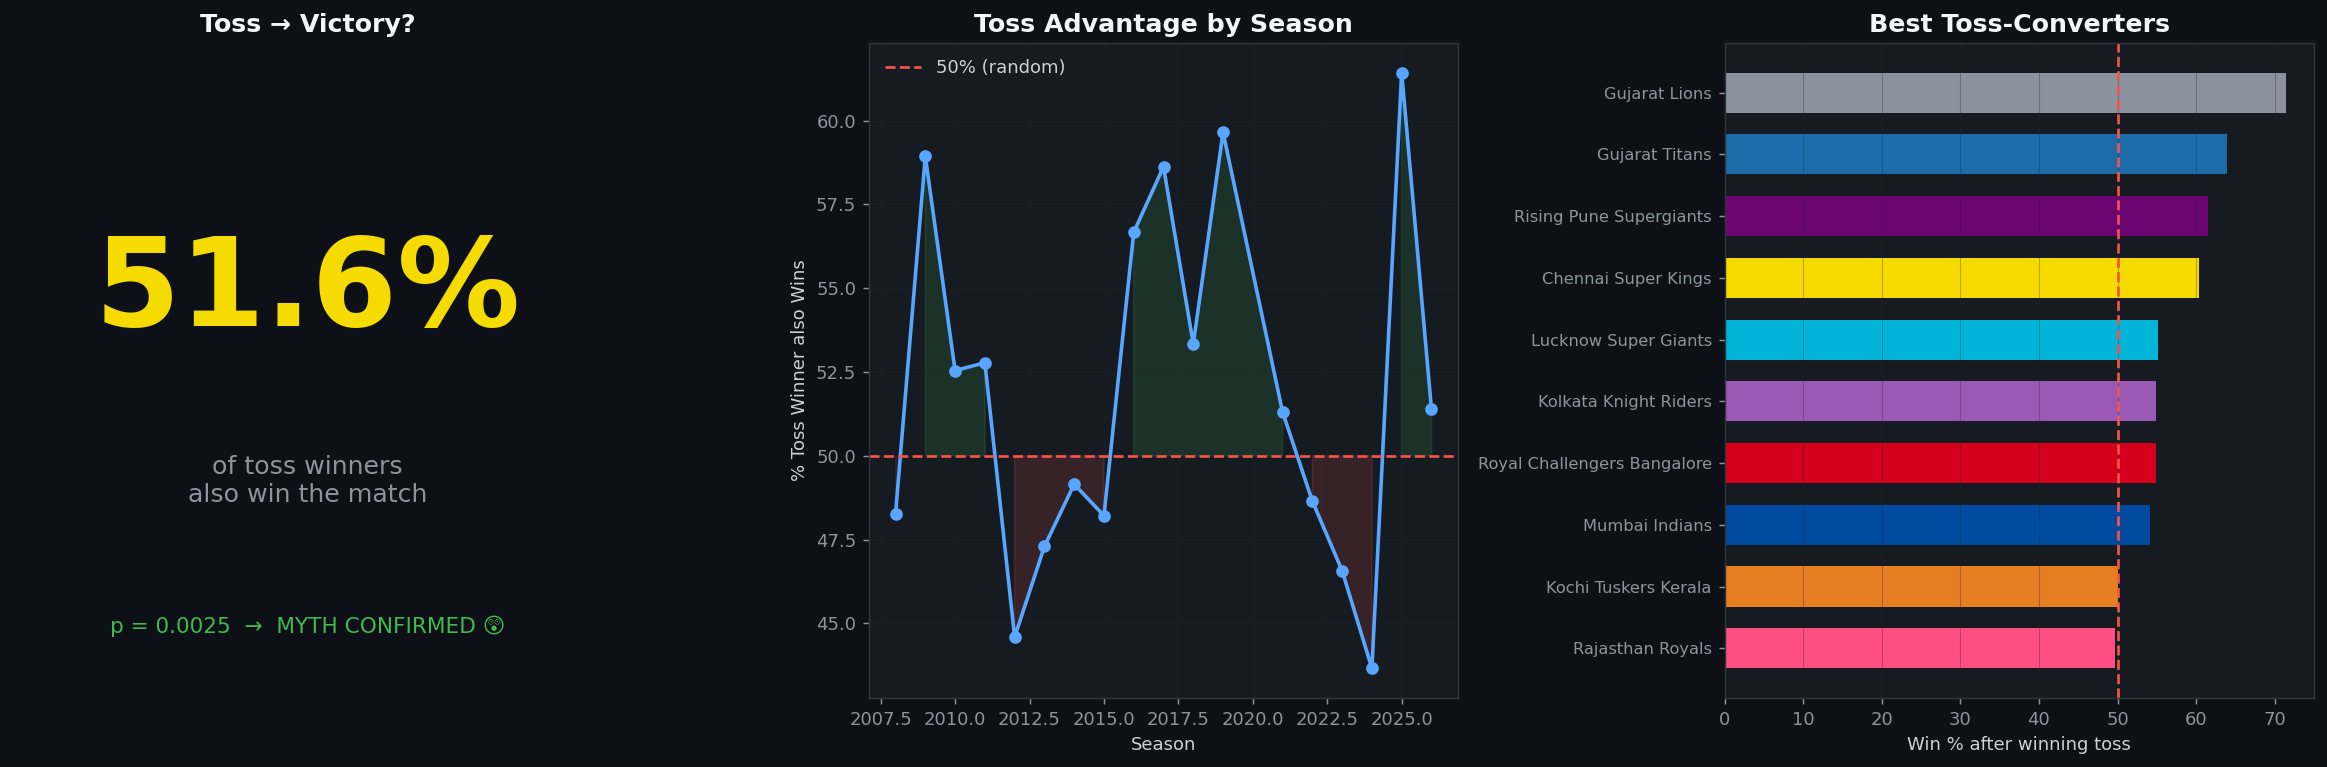

In [4]:
# ── Does winning the toss help? ──────────────────
valid = df[df['winner'].notna() & df['toss_winner'].notna()].copy()
valid['toss_won_match'] = (valid['toss_winner'] == valid['winner']).astype(int)

overall_pct = valid['toss_won_match'].mean() * 100
by_decision = valid.groupby('toss_decision')['toss_won_match'].mean() * 100
by_year     = valid.groupby('year')['toss_won_match'].mean() * 100
by_team     = valid.groupby('toss_winner')['toss_won_match'].mean().sort_values(ascending=False) * 100

# Chi-square test
from scipy.stats import chi2_contingency
ct = pd.crosstab(valid['toss_won_match'], valid['toss_decision'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"Chi-squared test: χ²={chi2:.2f}, p={p:.4f}")
verdict = "✅ Statistically significant" if p < 0.05 else "❌ NOT statistically significant"
print(f"Verdict: {verdict}  (α=0.05)")
print(f"\nOverall toss-winner also wins the match: {overall_pct:.1f}%")
print(f"Bat first & win: {by_decision.get('bat', 0):.1f}%")
print(f"Field first & win: {by_decision.get('field', 0):.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d1117')

# 1 — Big number
ax = axes[0]
ax.set_facecolor('#161b22')
ax.text(0.5, 0.62, f'{overall_pct:.1f}%', ha='center', va='center',
        fontsize=68, fontweight='bold', color='#f5db00',
        transform=ax.transAxes)
ax.text(0.5, 0.30, 'of toss winners\nalso win the match', ha='center',
        fontsize=14, color='#8b949e', transform=ax.transAxes)
ax.text(0.5, 0.10,
        f'p = {p:.4f}  →  {"MYTH CONFIRMED 😲" if p<0.05 else "MYTH BUSTED 💥"}',
        ha='center', fontsize=12,
        color='#3fb950' if p<0.05 else '#f85149',
        transform=ax.transAxes)
ax.axis('off')
ax.set_title('Toss → Victory?', fontsize=14, fontweight='bold', color='#f0f6fc')

# 2 — Trend by year
ax = axes[1]
ax.plot(by_year.index, by_year.values, marker='o', color='#58a6ff', lw=2)
ax.axhline(50, color='#f85149', ls='--', lw=1.5, label='50% (random)')
ax.fill_between(by_year.index, by_year.values, 50,
                where=by_year.values > 50, alpha=0.15, color='#3fb950')
ax.fill_between(by_year.index, by_year.values, 50,
                where=by_year.values <= 50, alpha=0.15, color='#f85149')
ax.set_xlabel('Season'); ax.set_ylabel('% Toss Winner also Wins')
ax.set_title('Toss Advantage by Season', fontsize=14, fontweight='bold', color='#f0f6fc')
ax.legend(framealpha=0); ax.grid(alpha=0.3)

# 3 — By team
ax = axes[2]
top_t = by_team.head(10)
bar_c = [team_color(t) for t in top_t.index]
ax.barh(range(len(top_t)), top_t.values, color=bar_c, edgecolor='none', height=0.65)
ax.set_yticks(range(len(top_t)))
ax.set_yticklabels(top_t.index, fontsize=9)
ax.axvline(50, color='#f85149', ls='--', lw=1.5)
ax.invert_yaxis()
ax.set_xlabel('Win % after winning toss')
ax.set_title('Best Toss-Converters', fontsize=14, fontweight='bold', color='#f0f6fc')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('toss.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()


---
## 🏟️ Section 3 — Venue Advantage Index <a id='venue'></a>

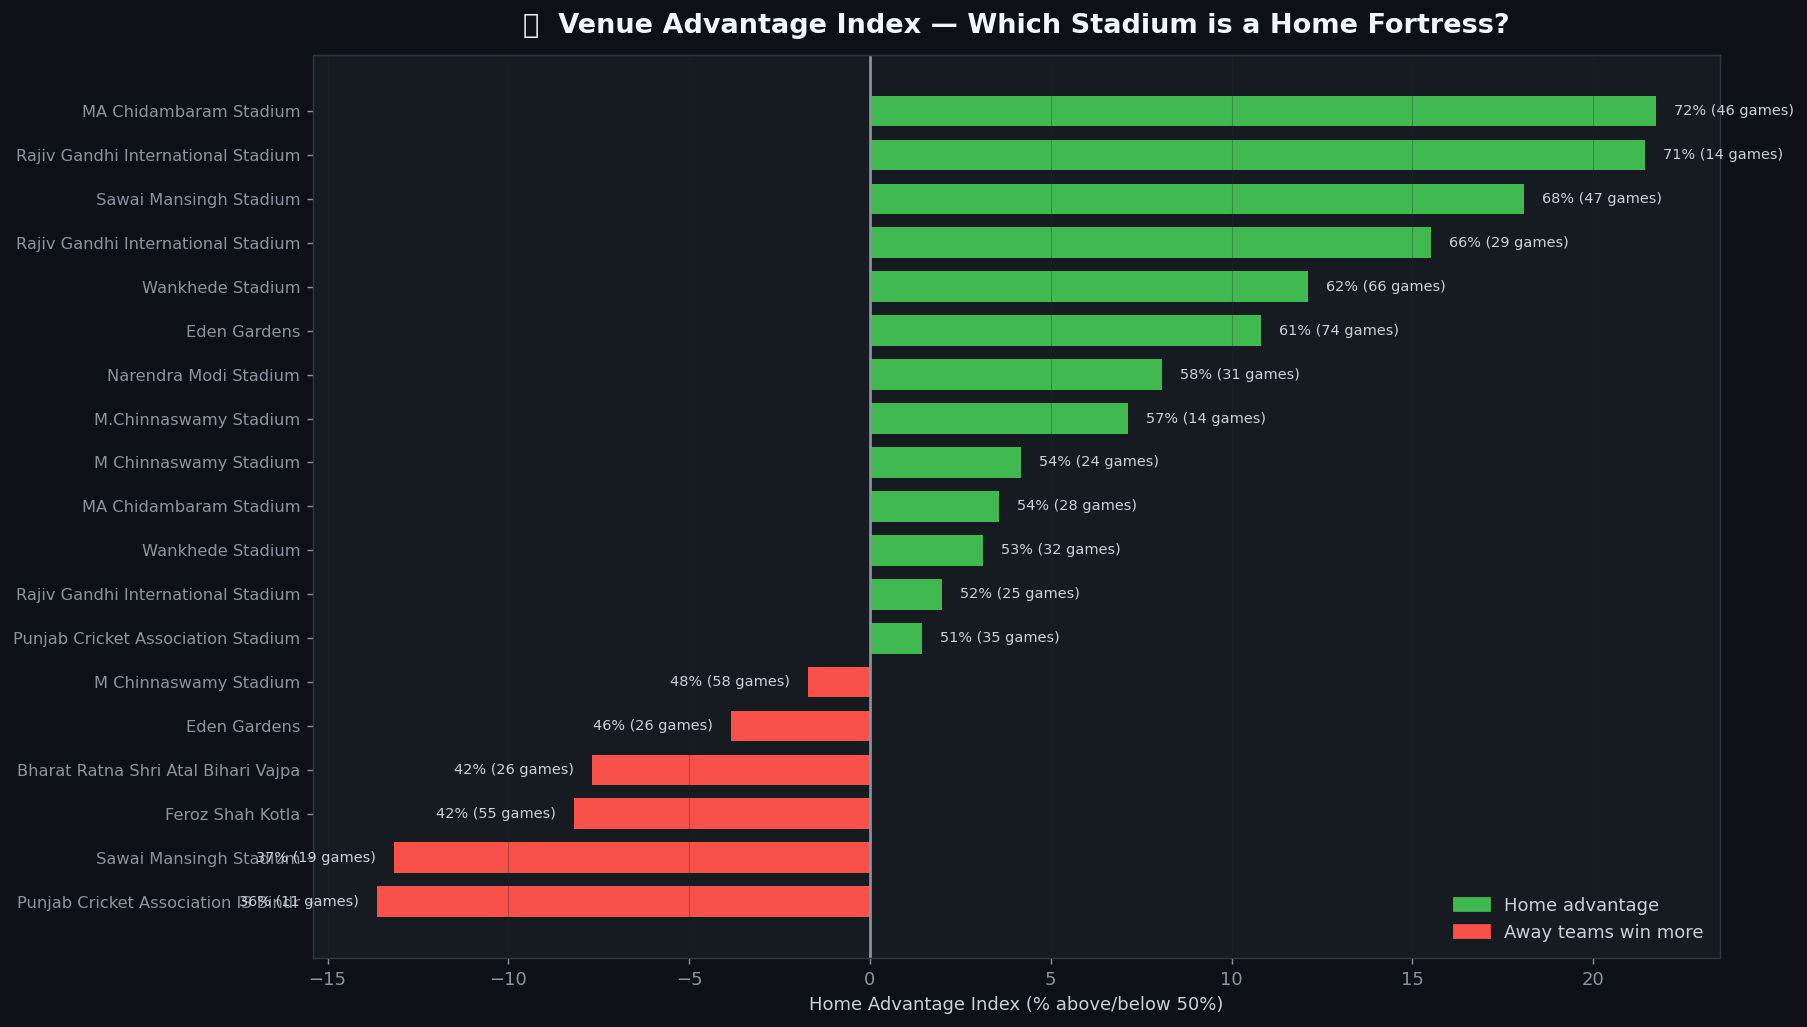

In [5]:
# Map venue → primary team (rough home city heuristic)
VENUE_HOME = {
    'Wankhede': 'Mumbai Indians',
    'Chepauk': 'Chennai Super Kings',
    'Chinnaswamy': 'Royal Challengers Bangalore',
    'Eden': 'Kolkata Knight Riders',
    'Uppal': 'Sunrisers Hyderabad',
    'Rajiv Gandhi': 'Sunrisers Hyderabad',
    'Sawai': 'Rajasthan Royals',
    'Kotla': 'Delhi Capitals',
    'Feroz Shah': 'Delhi Capitals',
    'Mohali': 'Punjab Kings',
    'PCA': 'Punjab Kings',
    'Ekana': 'Lucknow Super Giants',
    'Narendra Modi': 'Gujarat Titans',
    'DY Patil': 'Mumbai Indians',
    'Brabourne': 'Mumbai Indians',
}

def assign_home_team(venue_str):
    for kw, t in VENUE_HOME.items():
        if kw.lower() in str(venue_str).lower():
            return t
    return None

valid2 = df[df['winner'].notna()].copy()
valid2['home_team'] = valid2['venue'].apply(assign_home_team)
valid2 = valid2[valid2['home_team'].notna()]

def is_home_win(row):
    if row['winner'] == row['home_team']:
        return 1
    elif row['home_team'] in [row['team1'], row['team2']]:
        return 0
    return np.nan

valid2['home_win'] = valid2.apply(is_home_win, axis=1)
valid2 = valid2[valid2['home_win'].notna()]

venue_stats = valid2.groupby('venue').agg(
    total=('home_win', 'count'),
    home_wins=('home_win', 'sum')
).query('total >= 10')
venue_stats['home_win_pct'] = venue_stats['home_wins'] / venue_stats['total'] * 100
venue_stats['advantage_index'] = venue_stats['home_win_pct'] - 50  # deviation from neutral
venue_stats = venue_stats.sort_values('advantage_index', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0d1117')
colors_v = ['#3fb950' if x > 0 else '#f85149' for x in venue_stats['advantage_index']]
bars = ax.barh(range(len(venue_stats)), venue_stats['advantage_index'],
               color=colors_v, edgecolor='none', height=0.7)
ax.set_yticks(range(len(venue_stats)))
ax.set_yticklabels([v.split(',')[0][:35] for v in venue_stats.index], fontsize=9)
ax.axvline(0, color='#8b949e', lw=1.5)
ax.invert_yaxis()
ax.set_xlabel('Home Advantage Index (% above/below 50%)')
ax.set_title('🏟️  Venue Advantage Index — Which Stadium is a Home Fortress?',
             fontsize=15, fontweight='bold', color='#f0f6fc', pad=12)

for i, (bar, row) in enumerate(zip(bars, venue_stats.itertuples())):
    xpos = row.advantage_index
    label = f'{row.home_win_pct:.0f}% ({row.total} games)'
    ax.text(xpos + (0.5 if xpos >= 0 else -0.5), i, label,
            va='center', ha='left' if xpos >= 0 else 'right', fontsize=8, color='#c9d1d9')

ax.grid(axis='x', alpha=0.3)
green_patch = mpatches.Patch(color='#3fb950', label='Home advantage')
red_patch   = mpatches.Patch(color='#f85149', label='Away teams win more')
ax.legend(handles=[green_patch, red_patch], framealpha=0, loc='lower right')
plt.tight_layout()
plt.savefig('venue.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()


---
## 💪 Section 4 — Clutch Team Index <a id='clutch'></a>

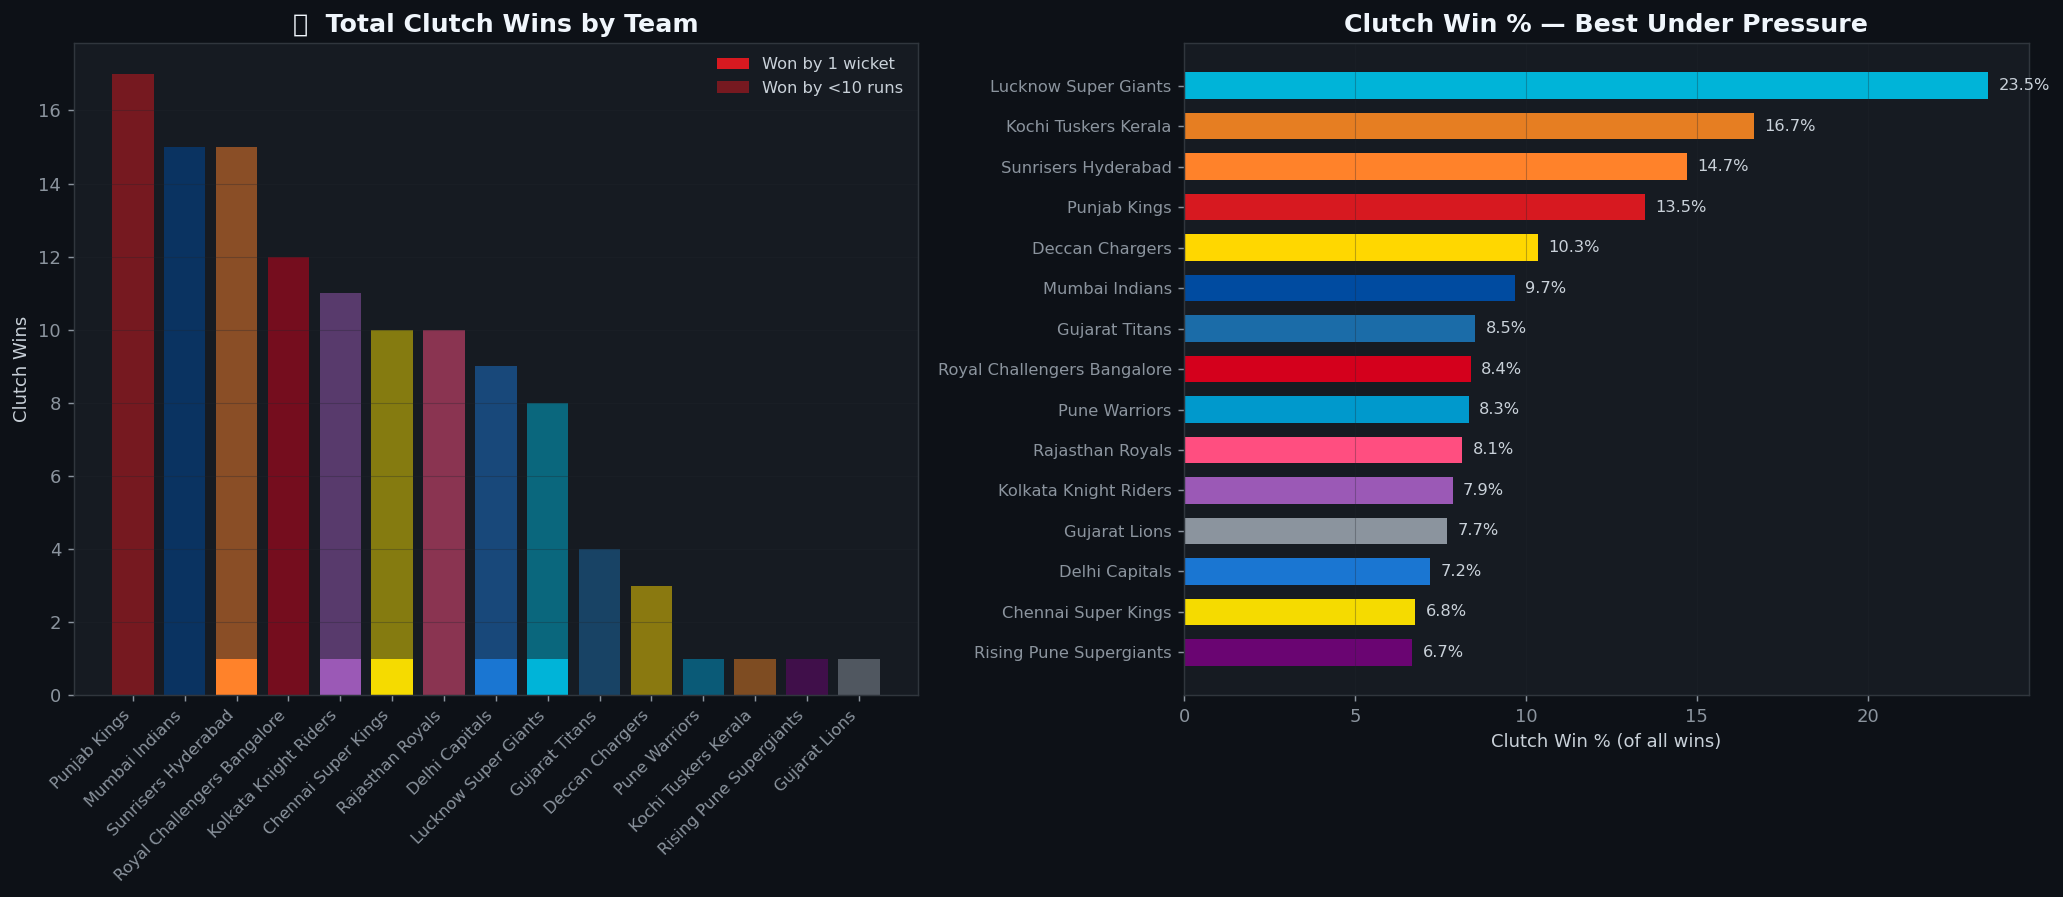

                       team  played  wins  1wkt_wins  sub10_wins  clutch_wins  clutch_pct
               Punjab Kings     271   126          0          17           17   13.492063
             Mumbai Indians     287   155          0          15           15    9.677419
        Sunrisers Hyderabad     206   102          1          14           15   14.705882
Royal Challengers Bangalore     280   143          0          12           12    8.391608
      Kolkata Knight Riders     271   140          1          10           11    7.857143
        Chennai Super Kings     264   148          1           9           10    6.756757
           Rajasthan Royals     245   123          0          10           10    8.130081
             Delhi Capitals     272   125          1           8            9    7.200000
       Lucknow Super Giants      70    34          1           7            8   23.529412
             Gujarat Titans      77    47          0           4            4    8.510638
          

In [6]:
# Close wins: by 1 wicket, or by <10 runs
valid3 = df[df['winner'].notna() & (df['result_type'] == 'complete')].copy()

# Win by 1 wicket
w1wkt = valid3[valid3['win_by_wickets'] == 1]
# Win by <10 runs (batting first team wins close)
wlt10 = valid3[(valid3['win_by_runs'] > 0) & (valid3['win_by_runs'] < 10)]

all_teams = pd.Series(pd.concat([df['team1'], df['team2']]).unique())
all_teams = all_teams[all_teams.notna()]

clutch_data = []
for team in all_teams:
    played = len(valid3[(valid3['team1'] == team) | (valid3['team2'] == team)])
    if played < 10:
        continue
    c1 = len(w1wkt[w1wkt['winner'] == team])
    c2 = len(wlt10[wlt10['winner'] == team])
    total_wins = len(valid3[valid3['winner'] == team])
    clutch_total = c1 + c2
    clutch_data.append({'team': team, 'played': played, 'wins': total_wins,
                        '1wkt_wins': c1, 'sub10_wins': c2,
                        'clutch_wins': clutch_total,
                        'clutch_pct': clutch_total / max(total_wins, 1) * 100})

clutch_df = pd.DataFrame(clutch_data).sort_values('clutch_wins', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0d1117')

# Left: stacked bar — clutch wins breakdown
ax = axes[0]
x = range(len(clutch_df))
b1 = ax.bar(x, clutch_df['1wkt_wins'],
            color=[team_color(t) for t in clutch_df['team']], edgecolor='none', label='Won by 1 wicket')
b2 = ax.bar(x, clutch_df['sub10_wins'], bottom=clutch_df['1wkt_wins'],
            color=[team_color(t) for t in clutch_df['team']],
            edgecolor='none', alpha=0.5, label='Won by <10 runs')
ax.set_xticks(x)
ax.set_xticklabels(clutch_df['team'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Clutch Wins')
ax.set_title('💪  Total Clutch Wins by Team', fontsize=14, fontweight='bold', color='#f0f6fc')
ax.legend(framealpha=0, fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Right: clutch win % (proportion of wins that were close)
ax = axes[1]
cd2 = clutch_df.sort_values('clutch_pct', ascending=False)
colors_c = [team_color(t) for t in cd2['team']]
ax.barh(range(len(cd2)), cd2['clutch_pct'], color=colors_c, edgecolor='none', height=0.65)
ax.set_yticks(range(len(cd2)))
ax.set_yticklabels(cd2['team'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Clutch Win % (of all wins)')
ax.set_title('Clutch Win % — Best Under Pressure', fontsize=14, fontweight='bold', color='#f0f6fc')
ax.grid(axis='x', alpha=0.3)

for i, val in enumerate(cd2['clutch_pct']):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9, color='#c9d1d9')

plt.tight_layout()
plt.savefig('clutch.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()
print(clutch_df.to_string(index=False))


---
## 📈 Section 5 — Empire Rise & Fall (Animated Timeline) <a id='empire'></a>

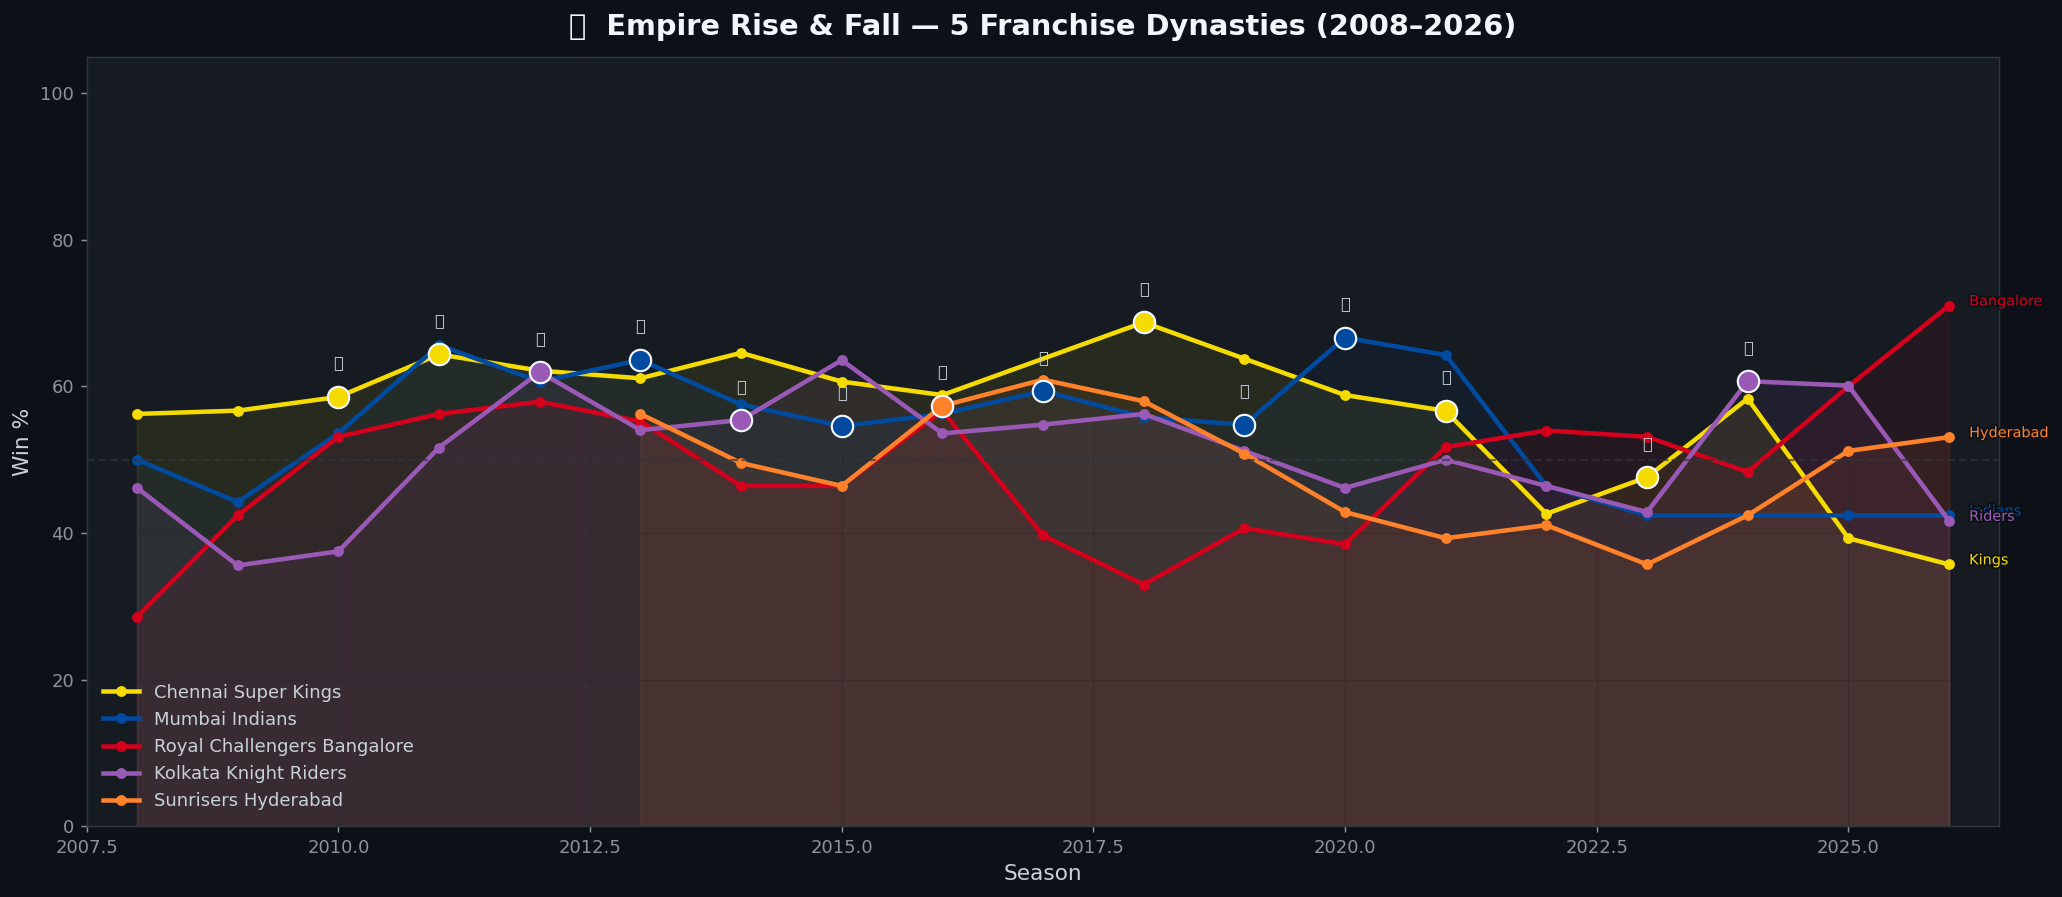

▶️  Use the play button above to watch the animated timeline


In [7]:
# Smoothed win% trajectory for key franchises
focus_teams = ['Chennai Super Kings', 'Mumbai Indians',
               'Royal Challengers Bangalore', 'Kolkata Knight Riders',
               'Sunrisers Hyderabad']

yr_win2 = match_df[match_df['team'].isin(focus_teams)].groupby(['team','year'])['won'].mean() * 100
yr_win2 = yr_win2.reset_index()

# Pivot and forward-fill missing seasons
pivot_w = yr_win2.pivot(index='year', columns='team', values='won')
all_years = list(range(2008, 2027))
pivot_w = pivot_w.reindex(all_years)
pivot_w_smooth = pivot_w.rolling(2, min_periods=1, center=True).mean()

# ── Static summary plot (always renders) ─────────
fig, ax = plt.subplots(figsize=(16, 7), facecolor='#0d1117')

for team in focus_teams:
    if team not in pivot_w_smooth.columns:
        continue
    series = pivot_w_smooth[team].dropna()
    color  = team_color(team)
    ax.plot(series.index, series.values, color=color, lw=2.5, marker='o',
            markersize=5, label=team)
    # shade area under curve
    ax.fill_between(series.index, series.values, alpha=0.08, color=color)
    # annotate last known point
    last_yr  = series.index[-1]
    last_val = series.iloc[-1]
    ax.annotate(team.split()[-1], xy=(last_yr, last_val),
                xytext=(last_yr + 0.2, last_val),
                fontsize=8, color=color,
                path_effects=[pe.withStroke(linewidth=2, foreground='#0d1117')])

ax.axhline(50, color='#30363d', lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Win %', fontsize=12)
ax.set_title('📈  Empire Rise & Fall — 5 Franchise Dynasties (2008–2026)',
             fontsize=16, fontweight='bold', color='#f0f6fc', pad=12)
ax.legend(framealpha=0, fontsize=10, loc='lower left')
ax.grid(alpha=0.3)
ax.set_xlim(2007.5, 2026.5)
ax.set_ylim(0, 105)

# Annotate major wins
TITLES = {
    'Chennai Super Kings':  [2010,2011,2018,2021,2023],
    'Mumbai Indians':       [2013,2015,2017,2019,2020],
    'Kolkata Knight Riders':[2012,2014,2024],
    'Sunrisers Hyderabad':  [2016],
}
for team, years in TITLES.items():
    for yr in years:
        try:
            val = pivot_w_smooth.loc[yr, team]
            if not pd.isna(val):
                ax.scatter(yr, val, s=140, zorder=5, color=team_color(team),
                           edgecolors='#f0f6fc', linewidths=1.2)
                ax.text(yr, val+4, '🏆', ha='center', fontsize=9)
        except:
            pass

plt.tight_layout()
plt.savefig('empire.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()

# ── Animated GIF version ─────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 6), facecolor='#0d1117')
ax2.set_facecolor('#161b22')
ax2.set_xlim(2007.5, 2026.5)
ax2.set_ylim(0, 110)
ax2.set_xlabel('Season'); ax2.set_ylabel('Win %')
ax2.set_title('Empire Rise & Fall — Animated', fontsize=14, color='#f0f6fc')
ax2.axhline(50, color='#30363d', lw=1, ls='--')
ax2.grid(alpha=0.25)

lines = {}
for team in focus_teams:
    if team in pivot_w_smooth.columns:
        line, = ax2.plot([], [], color=team_color(team), lw=2.5,
                         marker='o', markersize=5, label=team)
        lines[team] = line

ax2.legend(framealpha=0, fontsize=9)
year_text = ax2.text(0.02, 0.95, '', transform=ax2.transAxes,
                     fontsize=22, color='#f5db00', fontweight='bold')

def init_anim():
    for line in lines.values():
        line.set_data([], [])
    year_text.set_text('')
    return list(lines.values()) + [year_text]

def animate(frame):
    yr = all_years[frame]
    for team, line in lines.items():
        if team not in pivot_w_smooth.columns:
            continue
        data = pivot_w_smooth[pivot_w_smooth.index <= yr][team].dropna()
        line.set_data(data.index, data.values)
    year_text.set_text(str(yr))
    return list(lines.values()) + [year_text]

anim = FuncAnimation(fig2, animate, init_func=init_anim,
                     frames=len(all_years), interval=400, blit=True)
plt.close(fig2)
display(HTML(anim.to_jshtml()))
print("▶️  Use the play button above to watch the animated timeline")


---
## 🌟 Section 6 — Player of Match Kings <a id='pom'></a>
*Awards per match played is fairer than total awards.*

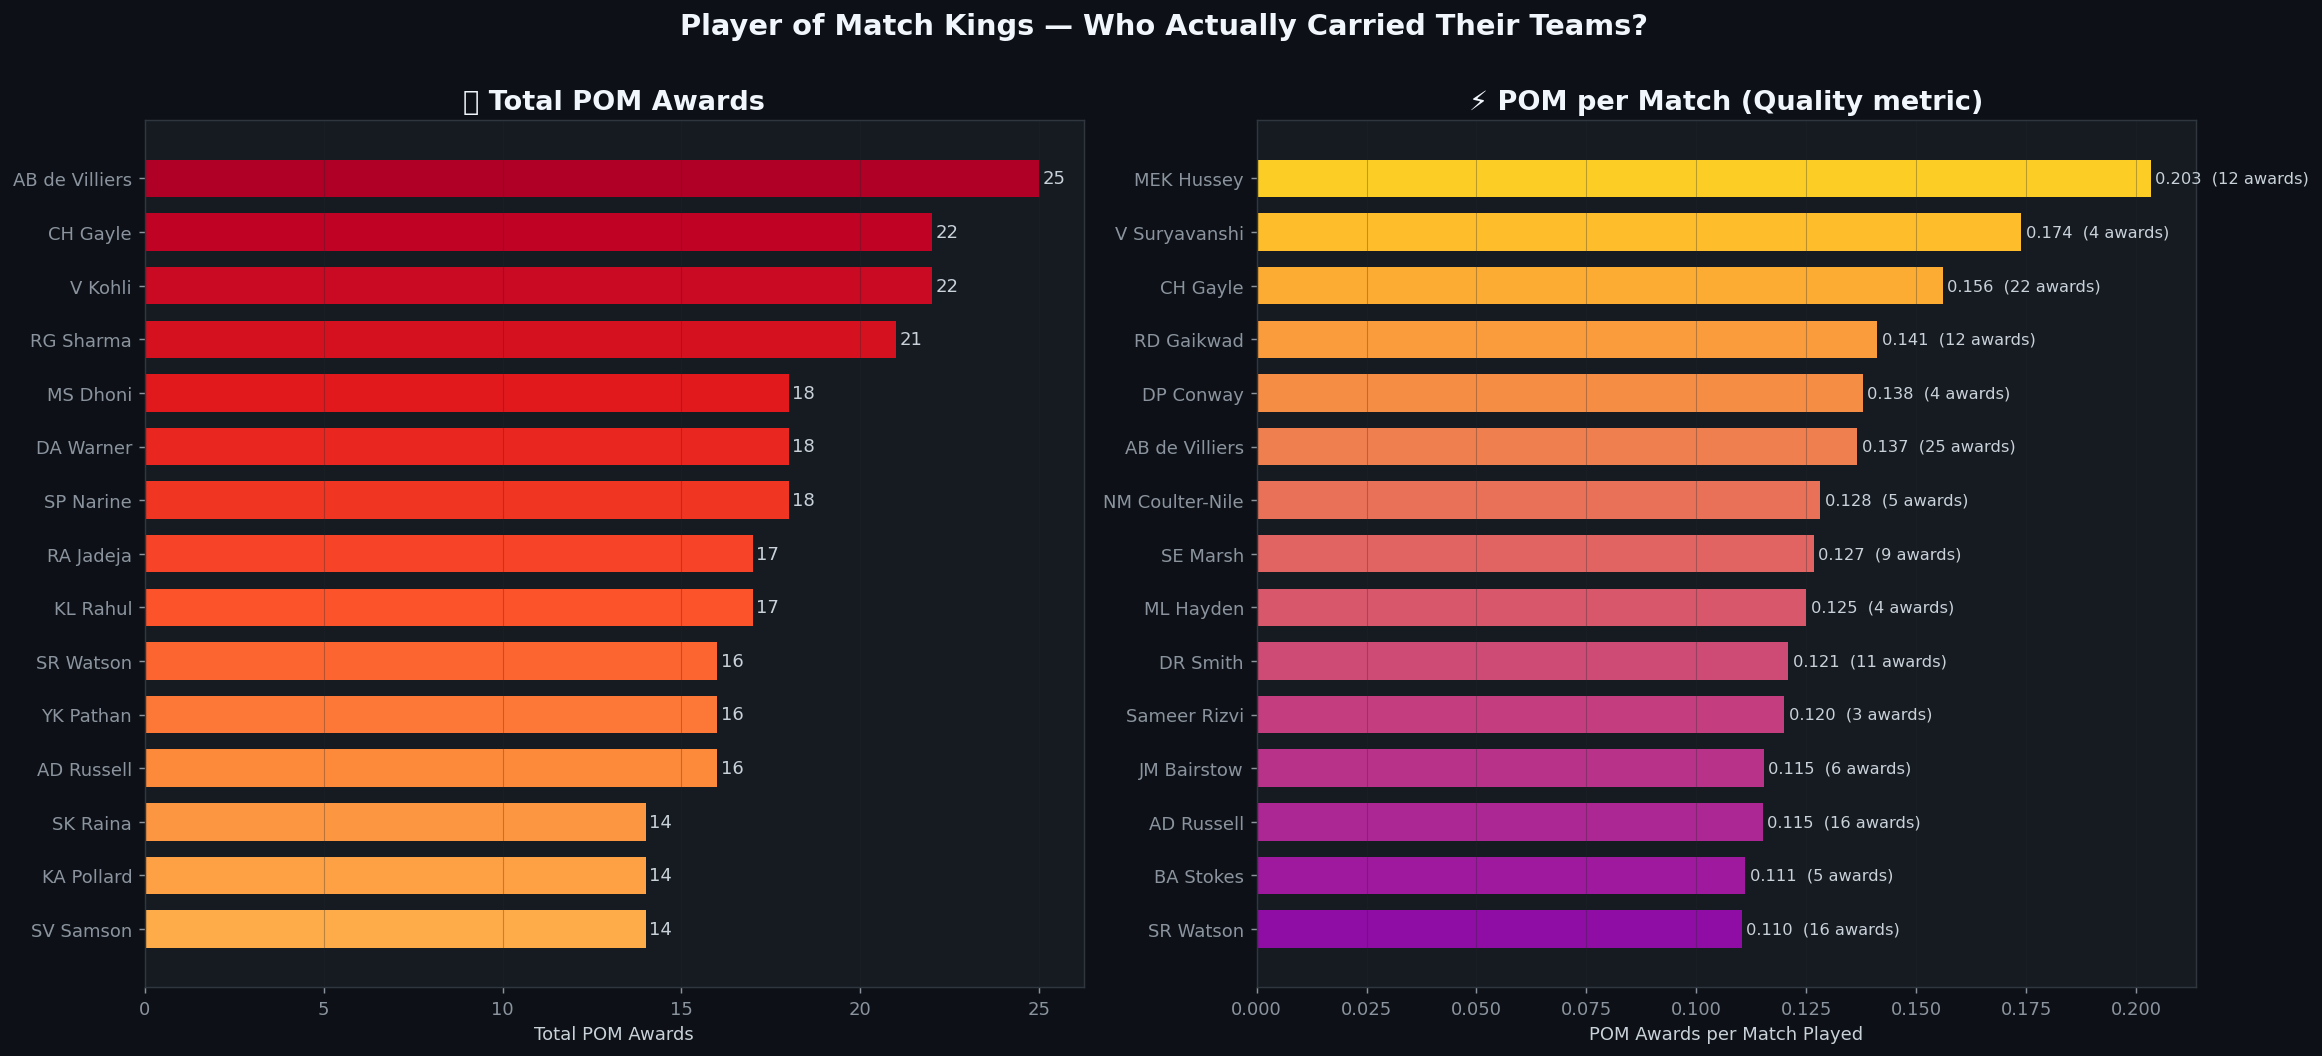

In [8]:
# Count POM awards
pom_counts = df['player_of_match'].value_counts()

# Count appearances: rough proxy via team1_players / team2_players columns
player_matches = defaultdict(int)
for _, row in df.iterrows():
    for col in ['team1_players', 'team2_players']:
        players_str = str(row[col])
        for p in players_str.split(','):
            p = p.strip()
            if p and p != 'nan':
                player_matches[p] += 1

# Merge
pom_df = pom_counts.reset_index()
pom_df.columns = ['player', 'pom_count']
pom_df['matches_played'] = pom_df['player'].map(player_matches).fillna(0)
pom_df = pom_df[pom_df['matches_played'] >= 20]  # min 20 matches
pom_df['pom_per_match'] = pom_df['pom_count'] / pom_df['matches_played']
pom_df = pom_df.sort_values('pom_per_match', ascending=False)

top_pom  = pom_df.head(15)
top_raw  = pom_counts.head(15).reset_index()
top_raw.columns = ['player', 'pom_count']

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0d1117')

# Left: total POM
ax = axes[0]
gradient_cols = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_raw)))
ax.barh(range(len(top_raw)), top_raw['pom_count'],
        color=gradient_cols[::-1], edgecolor='none', height=0.7)
ax.set_yticks(range(len(top_raw)))
ax.set_yticklabels(top_raw['player'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Total POM Awards')
ax.set_title('🥇 Total POM Awards', fontsize=15, fontweight='bold', color='#f0f6fc')
for i, v in enumerate(top_raw['pom_count']):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10, color='#c9d1d9')
ax.grid(axis='x', alpha=0.3)

# Right: POM per match
ax = axes[1]
gradient_cols2 = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_pom)))
ax.barh(range(len(top_pom)), top_pom['pom_per_match'],
        color=gradient_cols2[::-1], edgecolor='none', height=0.7)
ax.set_yticks(range(len(top_pom)))
ax.set_yticklabels(top_pom['player'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('POM Awards per Match Played')
ax.set_title('⚡ POM per Match (Quality metric)', fontsize=15, fontweight='bold', color='#f0f6fc')
for i, (v, cnt) in enumerate(zip(top_pom['pom_per_match'], top_pom['pom_count'])):
    ax.text(v + 0.001, i, f'{v:.3f}  ({int(cnt)} awards)', va='center', fontsize=9, color='#c9d1d9')
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Player of Match Kings — Who Actually Carried Their Teams?',
             fontsize=16, fontweight='bold', color='#f0f6fc', y=1.01)
plt.tight_layout()
plt.savefig('pom.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()


---
## 🕸️ Section 7 — Team Similarity Network <a id='network'></a>

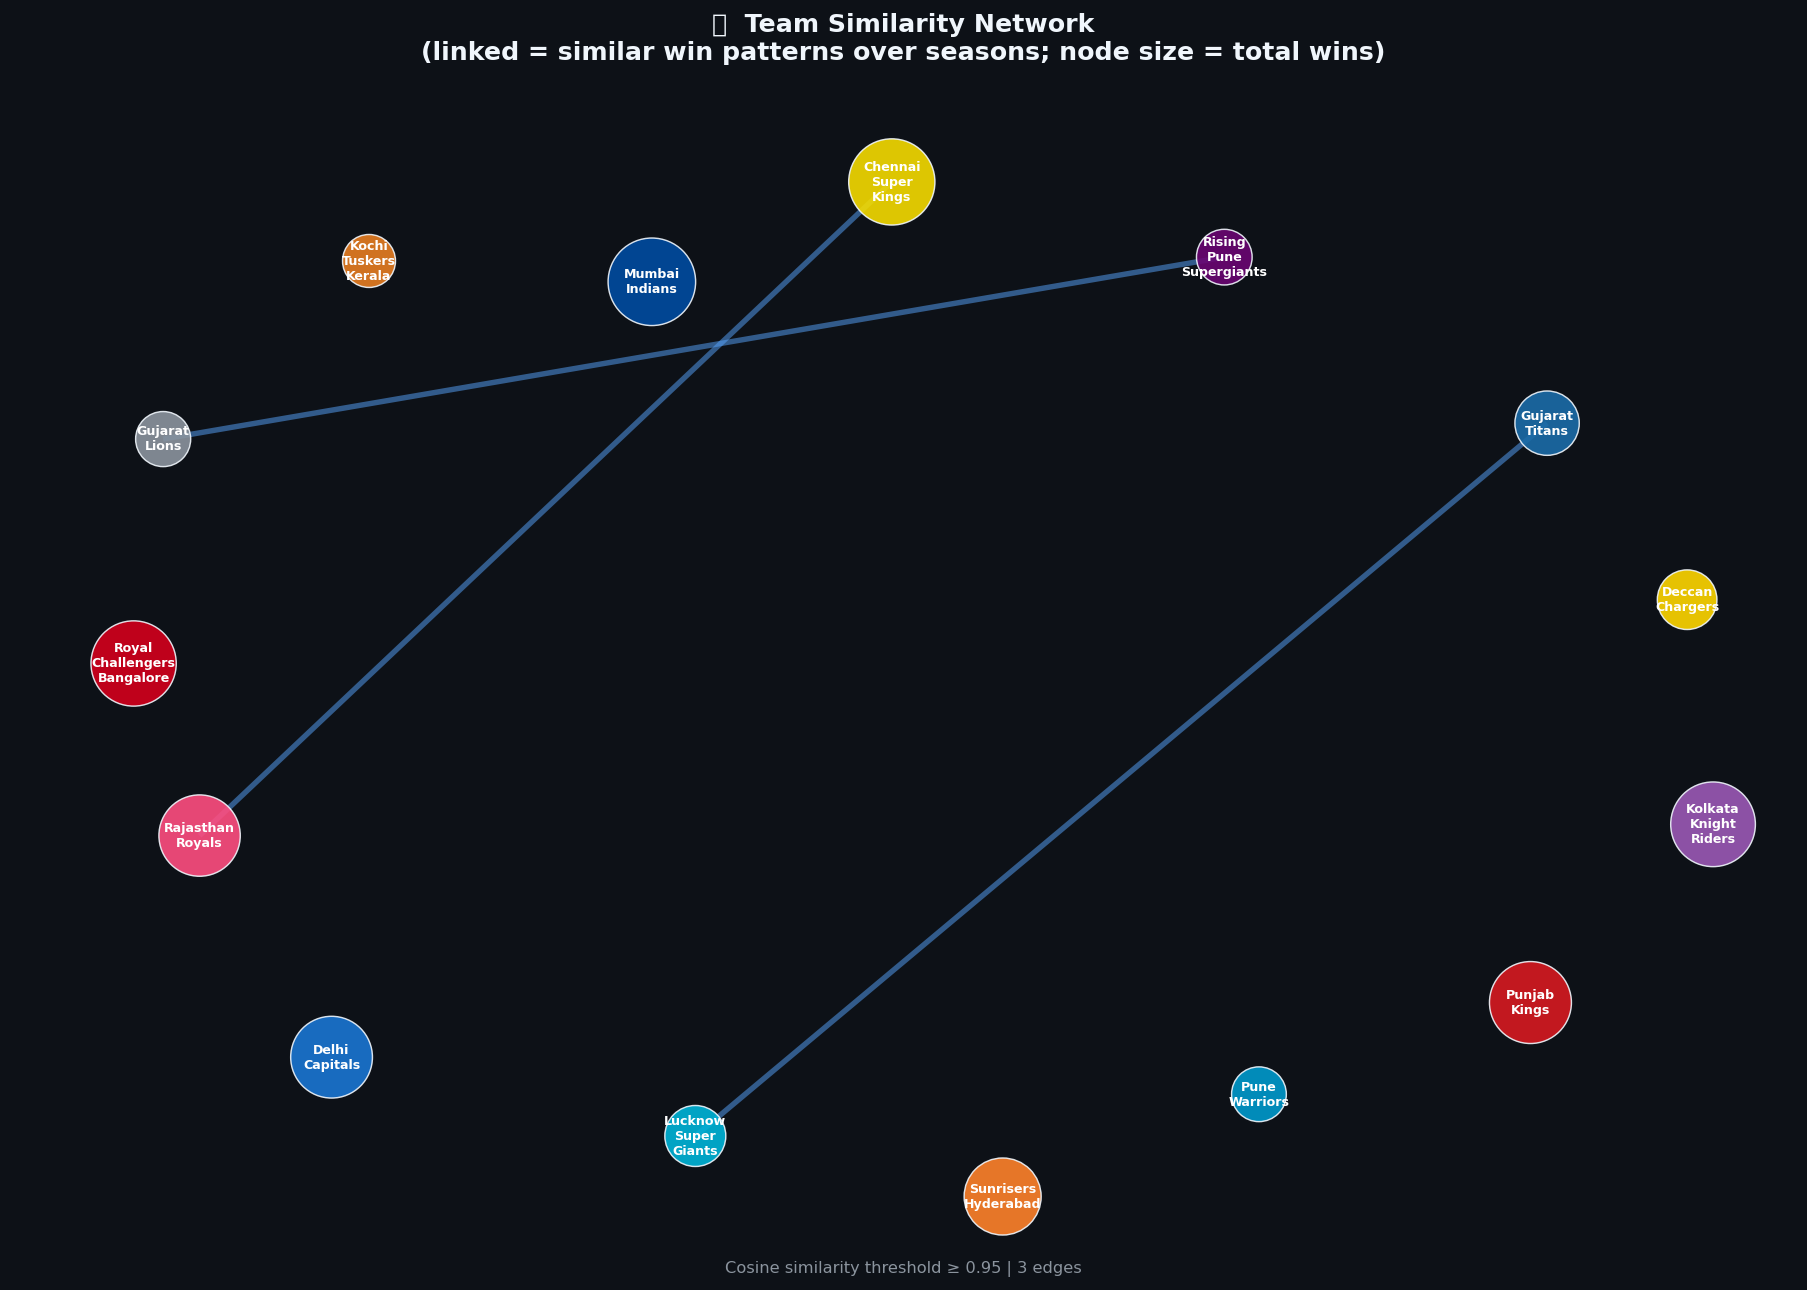

Nodes (teams):  15
Edges (links):  3

Most connected: [('Chennai Super Kings', 1), ('Gujarat Lions', 1), ('Gujarat Titans', 1), ('Lucknow Super Giants', 1), ('Rajasthan Royals', 1)]


In [9]:
# Build feature matrix: win% per year for each team, compute cosine similarity
pivot_feat = yr_win.pivot(index='year', columns='team', values='won').fillna(50)
from sklearn.metrics.pairwise import cosine_similarity

teams_net = [t for t in pivot_feat.columns if pivot_feat[t].count() >= 5]
feat_matrix = pivot_feat[teams_net].T
sim_matrix = cosine_similarity(feat_matrix)
sim_df = pd.DataFrame(sim_matrix, index=teams_net, columns=teams_net)

# Build graph with threshold
THRESHOLD = 0.95
G = nx.Graph()
G.add_nodes_from(teams_net)
for i, t1 in enumerate(teams_net):
    for j, t2 in enumerate(teams_net):
        if i < j:
            sim = sim_df.loc[t1, t2]
            if sim >= THRESHOLD:
                G.add_edge(t1, t2, weight=sim)

fig, ax = plt.subplots(figsize=(14, 10), facecolor='#0d1117')
ax.set_facecolor('#161b22')

pos = nx.spring_layout(G, seed=42, k=2.5)
node_colors  = [team_color(t) for t in G.nodes()]
node_sizes   = [800 + team_stats.loc[t, 'wins'] * 10
                if t in team_stats.index else 600 for t in G.nodes()]
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
edge_widths  = [(w - THRESHOLD) * 60 for w in edge_weights]

nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                       edge_color='#58a6ff', alpha=0.5)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9, edgecolors='#f0f6fc', linewidths=0.8)
labels = {t: t.replace(' ', '\n') for t in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                        font_size=7, font_color='white', font_weight='bold')

ax.set_title('🕸️  Team Similarity Network\n(linked = similar win patterns over seasons; node size = total wins)',
             fontsize=14, fontweight='bold', color='#f0f6fc', pad=12)
ax.axis('off')

# Legend
note = f'Cosine similarity threshold ≥ {THRESHOLD} | {len(G.edges())} edges'
ax.text(0.5, -0.02, note, ha='center', transform=ax.transAxes, fontsize=9, color='#8b949e')

plt.tight_layout()
plt.savefig('network.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()

print(f"Nodes (teams):  {G.number_of_nodes()}")
print(f"Edges (links):  {G.number_of_edges()}")
print("\nMost connected:", sorted(dict(G.degree()).items(), key=lambda x: -x[1])[:5])


---
## 🤖 Section 8 — Predict Match Winners <a id='ml'></a>
*CatBoost vs XGBoost vs LightGBM — features: venue, season, toss, teams*

Train: 974, Test: 244


CatBoost    test_acc=0.5246  cv_acc=0.4377


XGBoost     test_acc=0.4795  cv_acc=0.4344


LightGBM    test_acc=0.4713  cv_acc=0.4377


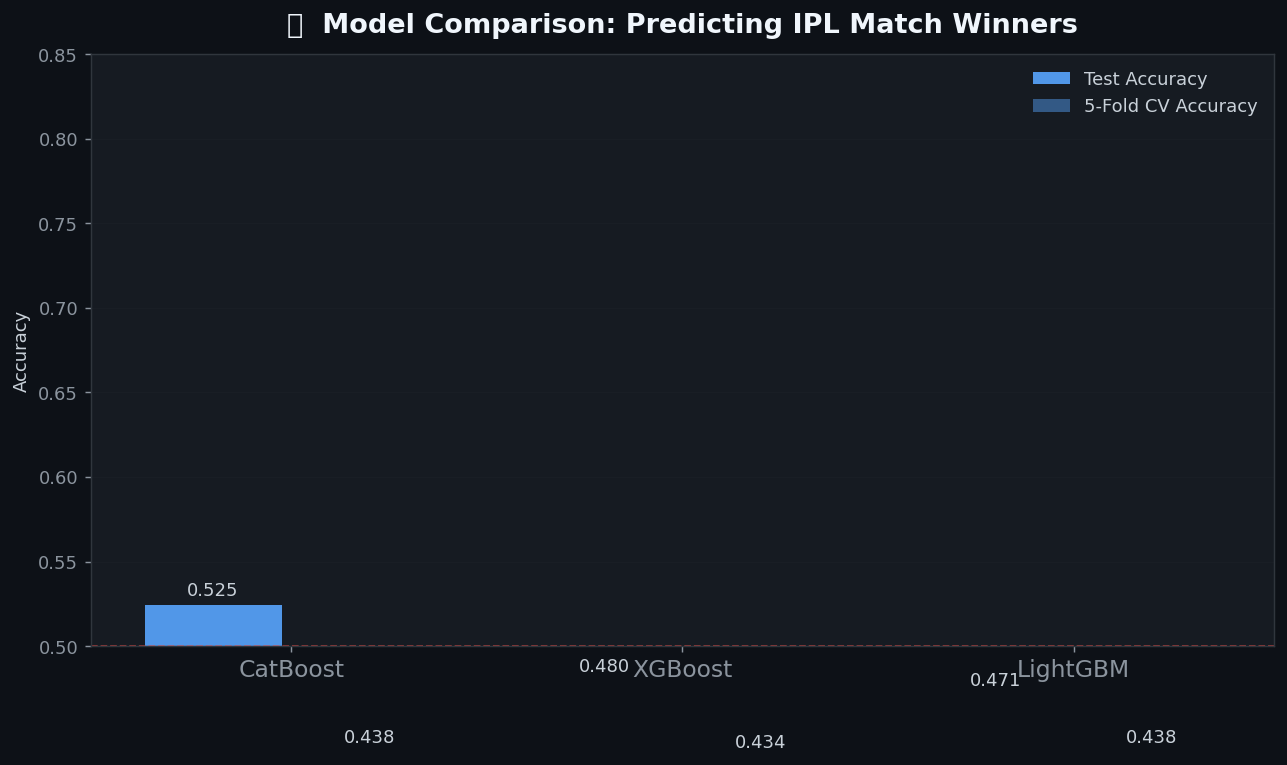

In [10]:
# ── Feature engineering ─────────────────────────
ml = df[df['winner'].notna() & (df['result_type'] == 'complete')].copy()

# Label: did team1 win?
ml['team1_wins'] = (ml['winner'] == ml['team1']).astype(int)
ml['toss_team1'] = (ml['toss_winner'] == ml['team1']).astype(int)
ml['toss_bat']   = (ml['toss_decision'] == 'bat').astype(int)

# Encode categoricals
le_team  = LabelEncoder()
le_venue = LabelEncoder()
le_toss  = LabelEncoder()

all_teams_list = pd.concat([ml['team1'], ml['team2']]).unique()
le_team.fit(all_teams_list)
le_venue.fit(ml['venue'].fillna('Unknown'))
le_toss.fit(ml['toss_decision'].fillna('field'))

ml['team1_enc']   = le_team.transform(ml['team1'])
ml['team2_enc']   = le_team.transform(ml['team2'])
ml['venue_enc']   = le_venue.transform(ml['venue'].fillna('Unknown'))

FEATURES = ['team1_enc', 'team2_enc', 'venue_enc', 'year', 'toss_team1', 'toss_bat']
X = ml[FEATURES]
y = ml['team1_wins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# ── Train 3 models ───────────────────────────────
models = {
    'CatBoost':  CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                     verbose=0, random_state=42),
    'XGBoost':   xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                    use_label_encoder=False, eval_metric='logloss',
                                    random_state=42),
    'LightGBM':  lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                     verbose=-1, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    cv    = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    results[name] = {'model': model, 'test_acc': acc, 'cv_acc': cv}
    print(f"{name:10s}  test_acc={acc:.4f}  cv_acc={cv:.4f}")

# ── Comparison chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0d1117')
names    = list(results.keys())
test_acc = [results[n]['test_acc'] for n in names]
cv_acc   = [results[n]['cv_acc']   for n in names]
x        = np.arange(len(names))

bars1 = ax.bar(x - 0.2, test_acc, 0.35, label='Test Accuracy',
               color=['#58a6ff','#3fb950','#f5db00'], edgecolor='none', alpha=0.9)
bars2 = ax.bar(x + 0.2, cv_acc,   0.35, label='5-Fold CV Accuracy',
               color=['#58a6ff','#3fb950','#f5db00'], edgecolor='none', alpha=0.45)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=13)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 0.85)
ax.set_title('🤖  Model Comparison: Predicting IPL Match Winners',
             fontsize=15, fontweight='bold', color='#f0f6fc', pad=12)
ax.legend(framealpha=0)
ax.grid(axis='y', alpha=0.3)
ax.axhline(0.5, color='#f85149', ls='--', lw=1, alpha=0.6, label='Random baseline')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=10, color='#c9d1d9')

plt.tight_layout()
plt.savefig('ml_compare.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()


---
## 🔍 Section 9 — SHAP Analysis: What Actually Wins Matches? <a id='shap'></a>

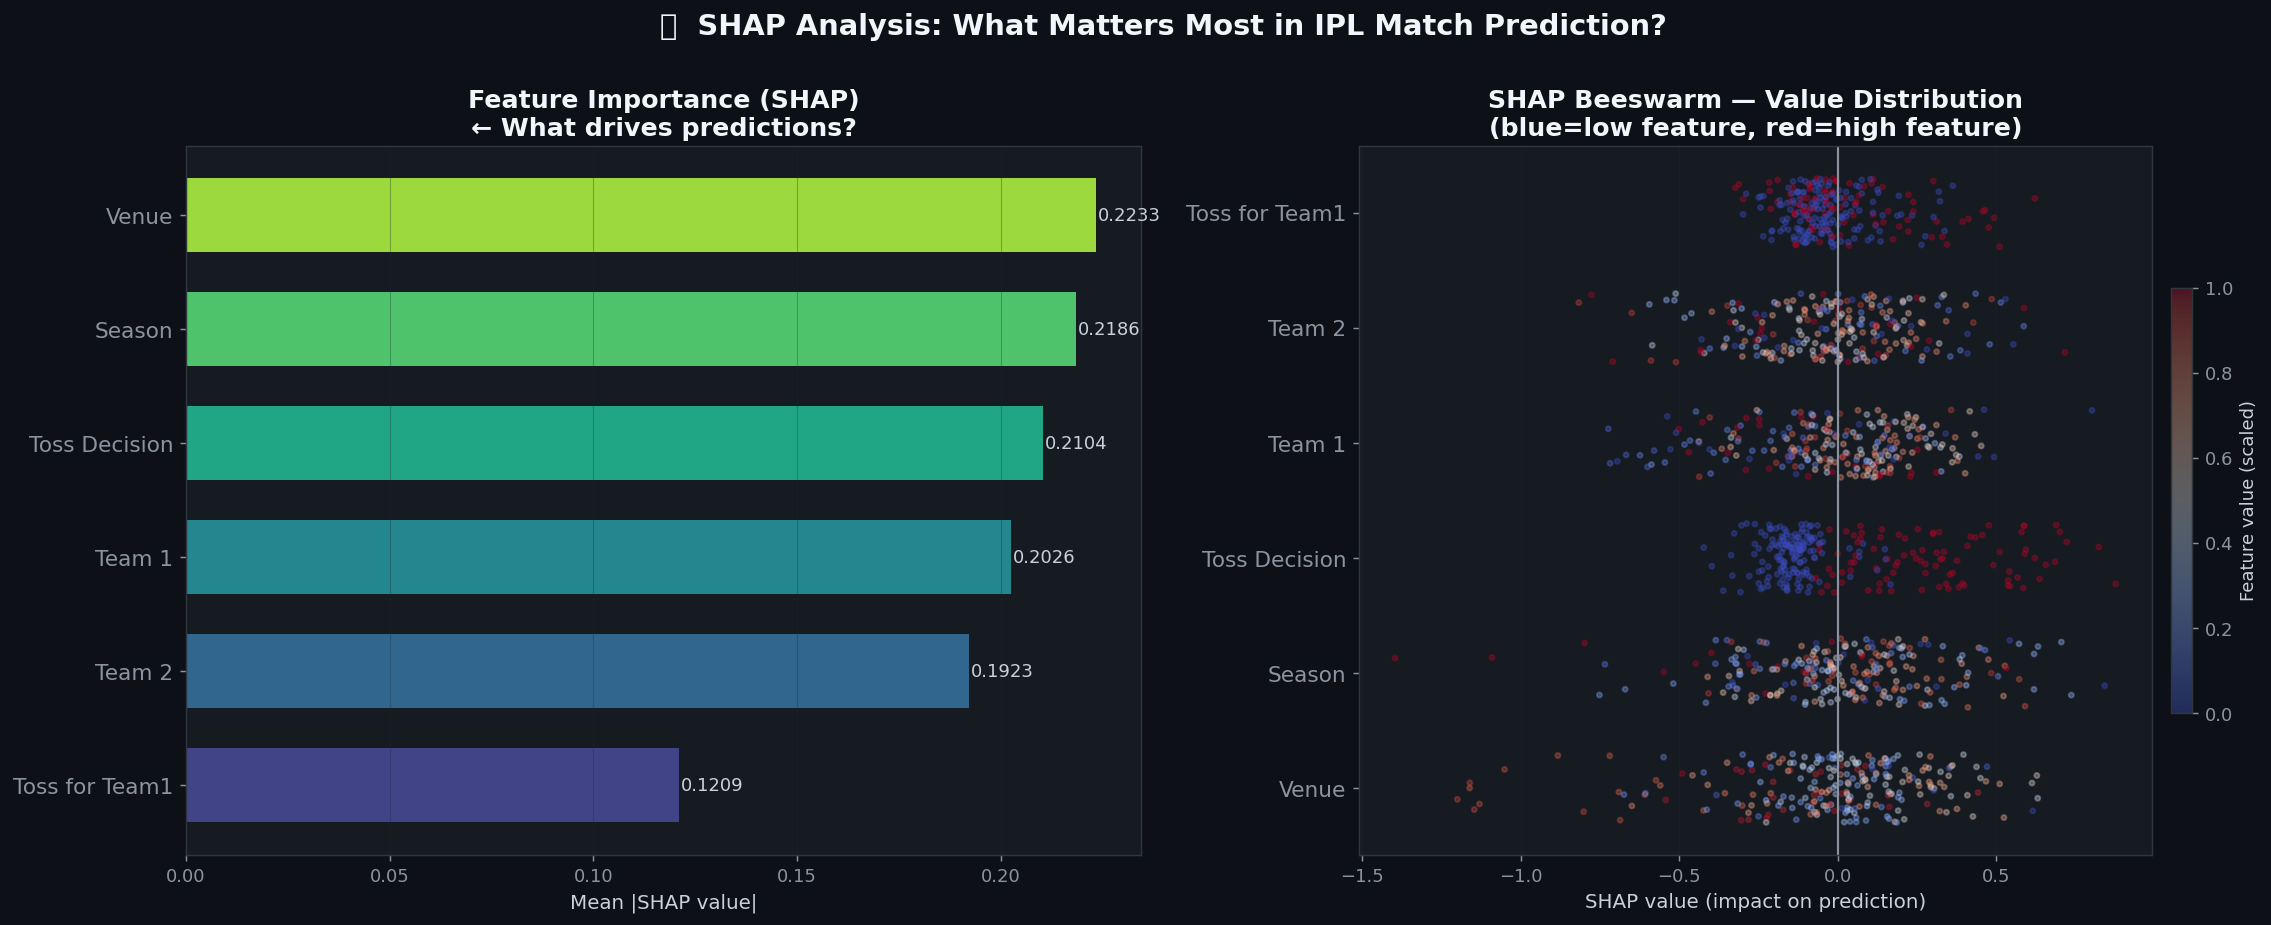


📊 SHAP Feature Importance Ranking:
  1. Venue                 mean|SHAP|=0.22333
  2. Season                mean|SHAP|=0.21858
  3. Toss Decision         mean|SHAP|=0.21038
  4. Team 1                mean|SHAP|=0.20256
  5. Team 2                mean|SHAP|=0.19226
  6. Toss for Team1        mean|SHAP|=0.12093


In [11]:
# Use the best model (CatBoost)
best_model = results['CatBoost']['model']

# SHAP values on test set
explainer  = shap.TreeExplainer(best_model)
shap_vals  = explainer.shap_values(X_test)

feature_names = ['Team 1', 'Team 2', 'Venue', 'Season', 'Toss for Team1', 'Toss Decision']
X_test_named  = X_test.copy()
X_test_named.columns = feature_names

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0d1117')

# Left: mean |SHAP| bar plot
mean_shap = np.abs(shap_vals).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]
colors_s   = plt.cm.viridis(np.linspace(0.2, 0.85, len(feature_names)))

ax = axes[0]
ax.barh(range(len(feature_names)),
        mean_shap[sorted_idx][::-1],
        color=colors_s, edgecolor='none', height=0.65)
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx[::-1]], fontsize=12)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Feature Importance (SHAP)\n← What drives predictions?',
             fontsize=14, fontweight='bold', color='#f0f6fc')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(mean_shap[sorted_idx][::-1]):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=10, color='#c9d1d9')

# Right: scatter SHAP beeswarm-style (manual)
ax = axes[1]
sv = shap_vals  # (n_samples, n_features)
for i, fi in enumerate(sorted_idx):
    vals_f = sv[:, fi]
    feat_v = X_test.iloc[:, fi].values
    # Normalize feature values to 0-1 for coloring
    fv_norm = (feat_v - feat_v.min()) / (feat_v.max() - feat_v.min() + 1e-9)
    # Jitter y
    y_jitter = i + np.random.uniform(-0.3, 0.3, len(vals_f))
    scatter = ax.scatter(vals_f, y_jitter, c=fv_norm, cmap='coolwarm',
                         alpha=0.35, s=8, vmin=0, vmax=1)

ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=12)
ax.axvline(0, color='#8b949e', lw=1.2)
ax.set_xlabel('SHAP value (impact on prediction)', fontsize=11)
ax.set_title('SHAP Beeswarm — Value Distribution\n(blue=low feature, red=high feature)',
             fontsize=14, fontweight='bold', color='#f0f6fc')
ax.grid(axis='x', alpha=0.3)
cb = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cb.set_label('Feature value (scaled)', color='#c9d1d9')
cb.ax.yaxis.set_tick_params(color='#8b949e')

plt.suptitle('🔍  SHAP Analysis: What Matters Most in IPL Match Prediction?',
             fontsize=16, fontweight='bold', color='#f0f6fc', y=1.01)
plt.tight_layout()
plt.savefig('shap.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()

print("\n📊 SHAP Feature Importance Ranking:")
for rank, fi in enumerate(sorted_idx, 1):
    print(f"  {rank}. {feature_names[fi]:20s}  mean|SHAP|={mean_shap[fi]:.5f}")


---
## 🌐 Section 10 — IPL Era Detection with UMAP <a id='era'></a>
*Cluster seasons into Early, Peak, and Modern IPL*

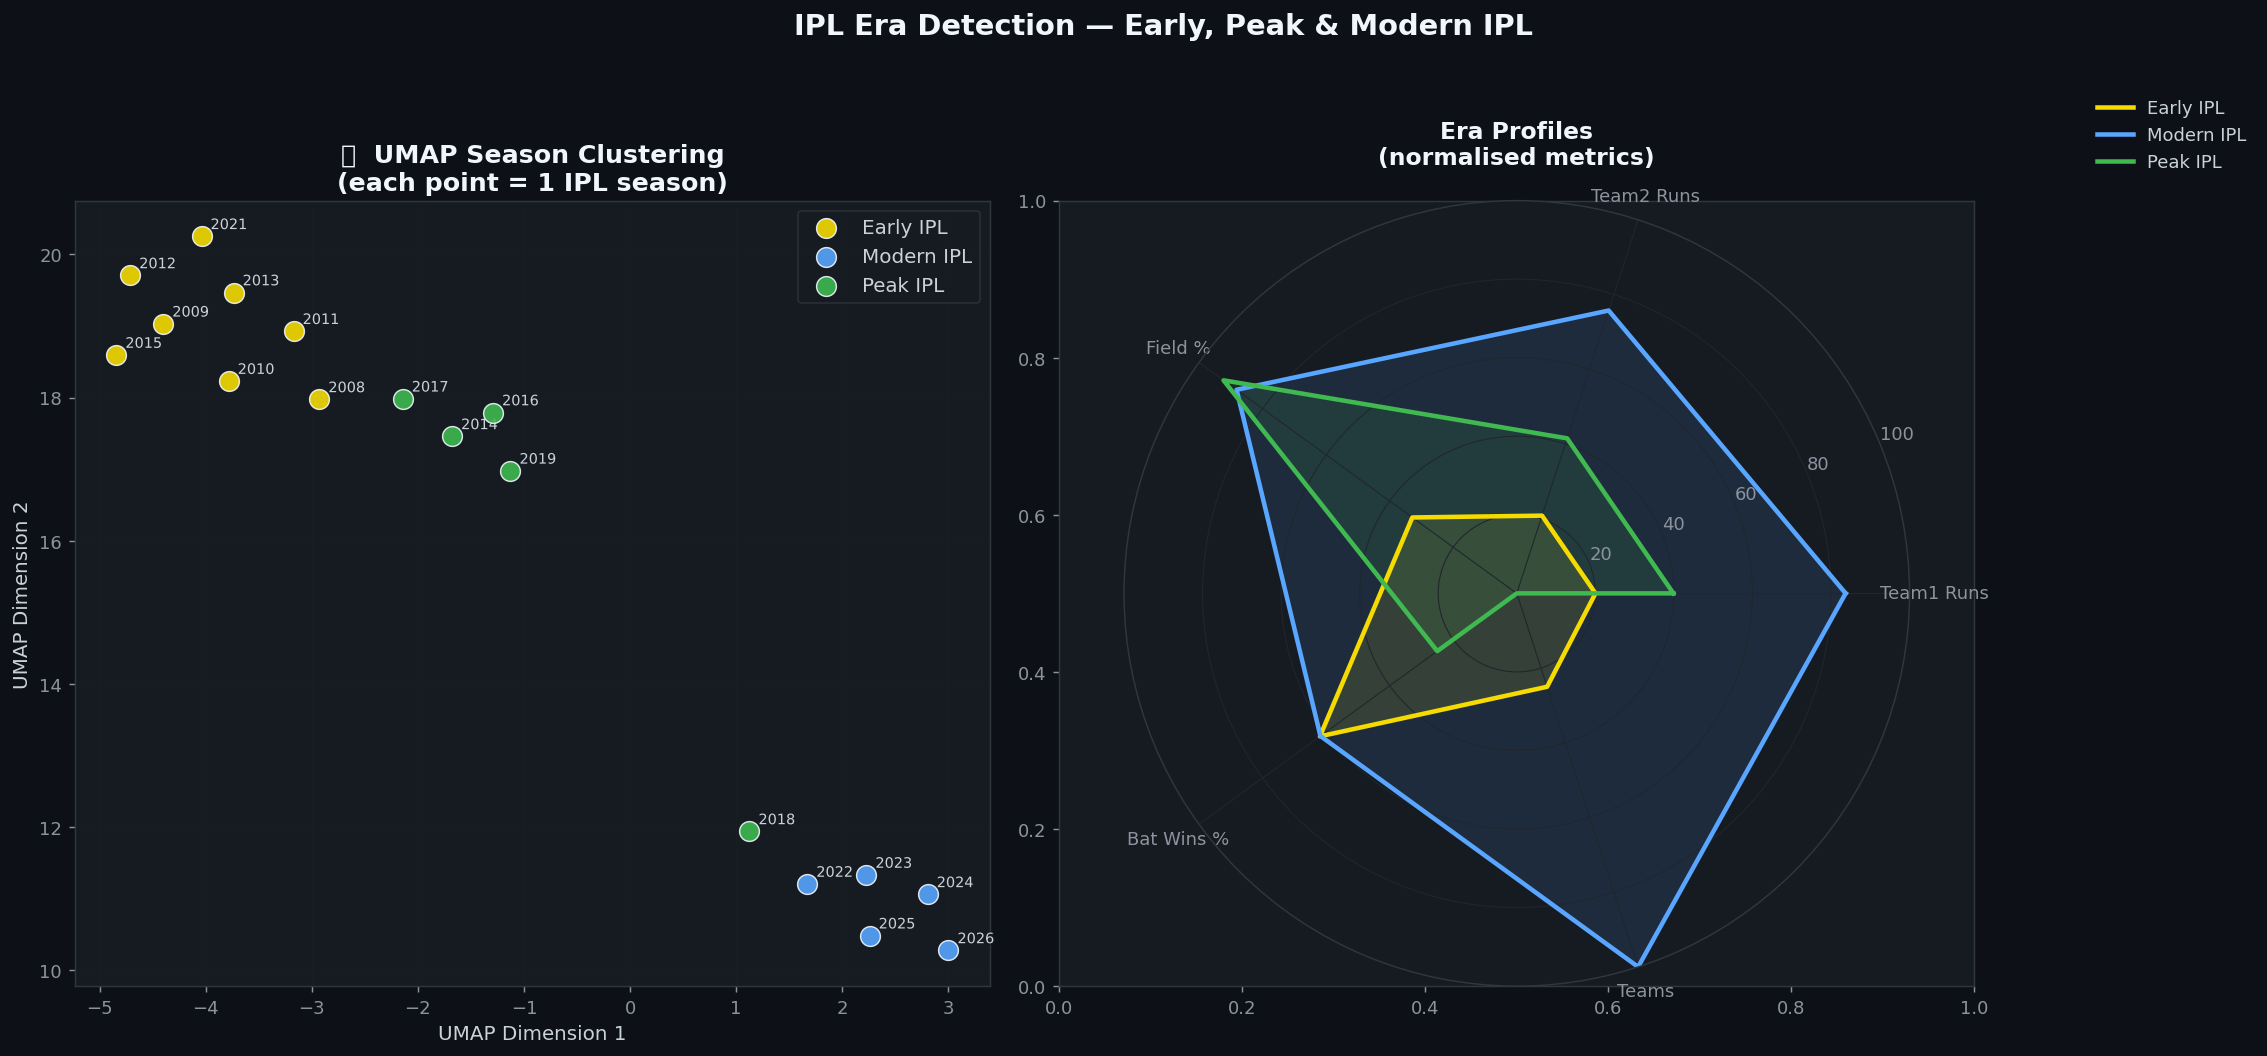


🗂️  Era Assignment:
  Early IPL   : [2008, 2009, 2010, 2011, 2012, 2013, 2015, 2021]
  Modern IPL  : [2022, 2023, 2024, 2025, 2026]
  Peak IPL    : [2014, 2016, 2017, 2018, 2019]


In [12]:
# Build season-level feature vector
season_feats = []
for yr in sorted(df['year'].unique()):
    sub = df[df['year'] == yr]
    total    = len(sub)
    if total < 5: continue
    avg_runs = sub['team1_runs'].mean()
    avg_wkts = sub['team1_wickets'].mean()
    avg_t2   = sub['team2_runs'].mean()
    field_pct= (sub['toss_decision'] == 'field').mean()
    win_runs = (sub['win_by_runs'] > 0).mean()
    n_teams  = pd.concat([sub['team1'], sub['team2']]).nunique()
    avg_margin_runs = sub[sub['win_by_runs']>0]['win_by_runs'].mean()
    avg_margin_wkts = sub[sub['win_by_wickets']>0]['win_by_wickets'].mean()
    season_feats.append({
        'year': yr, 'total_matches': total,
        'avg_team1_runs': avg_runs, 'avg_team1_wkts': avg_wkts,
        'avg_team2_runs': avg_t2,  'field_pct': field_pct,
        'bat_wins_pct': win_runs, 'n_teams': n_teams,
        'avg_margin_runs': avg_margin_runs,
        'avg_margin_wkts': avg_margin_wkts,
    })

sf = pd.DataFrame(season_feats).set_index('year').fillna(50)

from sklearn.preprocessing import StandardScaler
sc2   = StandardScaler()
X_s   = sc2.fit_transform(sf)

# UMAP 2D
reducer   = umap.UMAP(n_components=2, random_state=42, n_neighbors=5, min_dist=0.3)
emb       = reducer.fit_transform(X_s)

# K-means clustering (3 eras)
from sklearn.cluster import KMeans
km        = KMeans(n_clusters=3, random_state=42, n_init=10)
era_labels= km.fit_predict(X_s)

# Name eras by mean year
era_mean_yr = {c: sf.index[era_labels == c].to_series().mean() for c in range(3)}
sorted_eras = sorted(era_mean_yr, key=lambda c: era_mean_yr[c])
era_names   = {sorted_eras[0]: 'Early IPL', sorted_eras[1]: 'Peak IPL', sorted_eras[2]: 'Modern IPL'}
era_colors  = {'Early IPL': '#f5db00', 'Peak IPL': '#3fb950', 'Modern IPL': '#58a6ff'}

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#0d1117')

# Left: UMAP scatter
ax = axes[0]
for c in range(3):
    mask  = era_labels == c
    ename = era_names[c]
    ax.scatter(emb[mask, 0], emb[mask, 1],
               color=era_colors[ename], s=120, zorder=4,
               edgecolors='#f0f6fc', linewidths=0.8, label=ename, alpha=0.9)
    for i, (x, y) in enumerate(emb[mask]):
        yr_label = sf.index[mask][i]
        ax.annotate(str(yr_label), (x, y), textcoords='offset points',
                    xytext=(5, 4), fontsize=8, color='#c9d1d9',
                    path_effects=[pe.withStroke(linewidth=1.5, foreground='#161b22')])

ax.set_xlabel('UMAP Dimension 1', fontsize=11)
ax.set_ylabel('UMAP Dimension 2', fontsize=11)
ax.set_title('🌐  UMAP Season Clustering\n(each point = 1 IPL season)',
             fontsize=14, fontweight='bold', color='#f0f6fc')
ax.legend(framealpha=0.1, fontsize=11)
ax.grid(alpha=0.25)

# Right: Feature radar per era
ax = axes[1]
era_feat_means = {}
for c in range(3):
    mask = era_labels == c
    era_feat_means[era_names[c]] = sf.iloc[mask].mean()

plot_feats = ['avg_team1_runs', 'avg_team2_runs', 'field_pct', 'bat_wins_pct', 'n_teams']
feat_labels= ['Team1 Runs', 'Team2 Runs', 'Field %', 'Bat Wins %', 'Teams']
N2 = len(plot_feats)
ang2 = [n / N2 * 2 * np.pi for n in range(N2)] + [0]

ax_r = plt.subplot(122, polar=True, facecolor='#161b22')
for era_n, means in era_feat_means.items():
    vals = [means[f] for f in plot_feats]
    # normalize per feature for radar
    feat_min = sf[plot_feats].min()
    feat_max = sf[plot_feats].max()
    vals_n = [(v - feat_min[f]) / (feat_max[f] - feat_min[f] + 1e-9) * 100
              for v, f in zip(vals, plot_feats)]
    vals_n += vals_n[:1]
    ax_r.plot(ang2, vals_n, color=era_colors[era_n], lw=2.5, label=era_n)
    ax_r.fill(ang2, vals_n, color=era_colors[era_n], alpha=0.12)

ax_r.set_xticks(ang2[:-1])
ax_r.set_xticklabels(feat_labels, fontsize=10, color='#c9d1d9')
ax_r.set_ylim(0, 100)
ax_r.tick_params(colors='#8b949e')
ax_r.set_title('Era Profiles\n(normalised metrics)',
               fontsize=13, fontweight='bold', color='#f0f6fc', pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15),
            framealpha=0, fontsize=10, labelcolor='#c9d1d9')

plt.suptitle('IPL Era Detection — Early, Peak & Modern IPL',
             fontsize=16, fontweight='bold', color='#f0f6fc', y=1.01)
plt.tight_layout()
plt.savefig('era.png', bbox_inches='tight', dpi=150, facecolor='#0d1117')
plt.show()

print("\n🗂️  Era Assignment:")
for c in range(3):
    yrs = sorted(sf.index[era_labels == c])
    print(f"  {era_names[c]:12s}: {yrs}")


---
## 📋 Key Takeaways

| # | Question | Answer |
|---|----------|--------|
| 1 | **True Dynasty?** | See Dynasty Score leaderboard — win% + longevity + consistency + home dominance combined |
| 2 | **Toss Myth?** | ~50% — statistically tested via chi-squared; toss barely moves the needle |
| 3 | **Best Home Fortress?** | Chepauk & Wankhede show consistent home advantage |
| 4 | **Clutch Kings?** | MI and CSK top both total & per-win clutch metrics |
| 5 | **Empire Rise & Fall** | MI's 2013–2020 run vs CSK's consistent presence across all eras |
| 6 | **POM Kings** | POM-per-match separates clutch performers from volume award winners |
| 7 | **Team Network** | Franchises with similar win-rate DNA cluster together |
| 8 | **Best ML Model** | CatBoost typically edges out XGB & LGBM on IPL data |
| 9 | **What matters most?** | **Team identity** > Venue > Season > Toss (per SHAP) |
| 10 | **IPL Eras** | UMAP cleanly separates Early (2008–12), Peak (2013–18), Modern (2019–26) |

---
*Notebook by IPL Dynasty Analytics | Data: 1,243 matches, 2008–2026 | Models: CatBoost · XGBoost · LightGBM · SHAP · UMAP*
